![imagen](fotos/IMAGEN_vinos-tinto.jpg)

# CALIDAD DEL VINO TINTO

## 1. DESCRIPCION

El conjunto de datos nos da información sobre el vino tinto portugués. A partir de propiedades fisico-químicas se va a intentar determinar la calidad del vino.

## 2. DATOS

Debido a cuestiones de privacidad y logística, solo se dispone de variables fisicoquímicas (insumos) y sensoriales (resultados)

El conjunto de datos utilizados proviene de un dataset alojado en Kaggle con el fin de determinar la calidad del vino tinto. Este conjunto de datos también está disponible en el repositorio de aprendizaje automático de la UCI, https://archive.ics.uci.edu/ml/datasets/wine+quality .

El archivo extraido de Kaggle es:

> winequality-red.csv

### **ANALISIS GENERAL DE LOS DATOS**

Se analiza el dataset que hemos extraido de Kaggle.

En esta sección se importan las librerías necesarias para el análisis de los datos y se carga el dataset que hemos extraido de Kaggle sobre la calidad de vinos tintos.


### 2.1 IMPORTACION DE LIBRERIAS

In [55]:
import pandas as pd

In [56]:
# Visualización 
import matplotlib.pyplot as plt 
import seaborn as sns

In [22]:
# Configuración visual
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10,6)



### 2.2 CARGA DEL DATASET

In [57]:
df = pd.read_csv ("data/winequality-red.csv", sep=",")
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [58]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


La función head( ) permite visualizar las primeras filas para entender la estructura de los datos.

In [59]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


Dimensiones del dataset:


In [60]:
df.shape

(1599, 12)

La función shape( ) nos devuelve el número de filas y de columnas del dataset.

Ahora se verifica si existen valores faltantes en el dataset:

In [61]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

No existen valores nulos en el dataset como también hemos visto con la función info( )

Ahora se verifica si el dataset tiene registros duplicados:


In [65]:
df.duplicated().sum()

np.int64(240)

Nuestro dataset si tiene registros duplicados que tenemos que eliminar porque afectan al rendimiento de los modelos de Machine Learning.

In [62]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


La función describe( ) genera estadísticas básicas que nos ayudan a entender la distribución de las variables:

- media
- desviación estándar
- mínimo
- máximo
- percentiles



### 2.3 Análisis del cojunto de datos

El análisis del conjunto del dataset nos permite verificar si existen problemas en la calidad de los datos.

- 1599 REGISTROS

- 12 COLUMNAS

- SIN VALORES NULOS

- VARIABLES NUMERICAS:

    - 11 VARIABLES FLOAT:
    
        - fixed acidity
    
        - volatile acidity

        - citric acid

        - residual sugar

        - chlorides

        - free sulfur dioxide

        - total sulfur dioxide

        - density

        - pH

        - sulphates

        - alcohol

    - 1 VARIABLE INT:

        - quality
    

Las VARIABLES (COLUMNAS) se dividen en:

- Variables fisicoquímicas:

    - fixed acidity  &rarr;  acidez fija
    - volatile acidity  &rarr;  acidez volátil
    - citric acid  &rarr;  ácido cítrico  
    - residual sugar  &rarr;  azúcar residual
    - chlorides  &rarr;  cloruros
    - free sulfur dioxide  &rarr;  dióxido de azufre libre
    - total sulfur dioxide  &rarr;  dióxido de azufre total
    - density  &rarr;  densidad
    - pH
    - sulphates  &rarr;  sulfatos
    - alcohol

- Variable sensorial:

    - quality  &rarr;  calidad 

## 3. MODIFICACIONES EN LOS DATOS

Como hemos visto antes en el apartado 2.2 nuestro dataset si tiene registros duplicados. Dichos registros se eliminan porque afectan al rendimiento de los modelos de Machine Learning.

In [66]:
# se eliminan registros duplicados
df_1 = df.drop_duplicates()

Las nuevas dimensiones de nuestro dataset:

In [67]:
df_1.shape

(1359, 12)

Se tiene en nuestro dataset:

- 1359 registros NO duplicados
- 12 columnas

Se pasa el dataset a español renombrando las columnas de la siguiente manera:

> - fixed acidity  &rarr;  acidez_fija
> - volatile acidity  &rarr;  acidez_volatil
> - citric acid  &rarr;  acido_citrico
> - residual sugar  &rarr;  azucar_resid
> - chlorides  &rarr; cloruros
> - free sulfur dioxide  &rarr;  dioxido_azufre_libre
> - total sulfur dioxide  &rarr;  dioxido_azufre_total
> - density  &rarr;  densidad
> - sulphates  &rarr;  sulfatos
> - quality  &rarr;  calidad


In [68]:
# Renombrar columnas en español
df_e = df_1.rename(columns={
    'fixed acidity': 'acidez_fija', 
    'volatile acidity': 'acidez_volatil',
    'citric acid': 'acido_citrico',
    'residual sugar': 'azucar_resid',
    'chlorides': 'cloruros',
    'free sulfur dioxide': 'dioxido_azufre_libre',
    'total sulfur dioxide': 'dioxido_azufre_total',
    'density': 'densidad',
    'sulphates': 'sulfatos',
    'quality' : 'calidad'})




In [69]:
df_e

,acidez_fija,acidez_volatil,acido_citrico,azucar_resid,cloruros,dioxido_azufre_libre,dioxido_azufre_total,densidad,pH,sulfatos,alcohol,calidad
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
5,7.4,0.660,0.00,1.8,0.075,13.0,40.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1593,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


Una vez limpio nuestro dataset se guarda en un nuevo DataFrame llamado df_e. De esta manera cuando necesitemos leer el DataFrame no es necesario realizar todas las operaciones de limpieza. y partimos de nuestro DataFrame limpio.

In [70]:
# Guarda el DataFrame limpio y traducido sin la columna de índices automáticos
df_e.to_csv("data_new/df_e.csv", index=False)

## 4. ANALISIS DE LAS VARIABLES

En el análisis de las variables se miran los valores entre los que se mueve la variable y el número de veces que se repiten los valores. También se analizan dichas variables mediante los gráficos:

- HISTOGRAMAS:

Un histograma muestra la distribución de frecuencia de una variable numérica. Permite identificar patrones en los datos, como concentración de observaciones, dispersión, asimetría y posibles valores atípicos.

- BOXPLOTS:

Los boxplots permiten analizar la dispersión y distribución de las variables numéricas mediante la mediana, el rango intercuartílico y la detección de valores atípicos. Los puntos alejados de los bigotes representan posibles outliers, mientras que la posición de la mediana y la forma de la caja ayudan a identificar asimetrías en la distribución de los datos.

In [71]:
import pandas as pd
df_e = pd.read_csv ("data_new/df_e.csv")


### 4.1 ANALISIS UNIVARIABLE 

### 4.1.1 VARIABLE  $\Rightarrow$  fixed acidity  &rarr;  acidez fija

In [72]:
# Valor minimo de la acidez fija
ac_fi_min = df_e['acidez_fija'].min()
print(f"Valor mínimo de la acidez fija: {ac_fi_min}")

# Valor maximo de la acidez fija
ac_fi_max = df_e['acidez_fija'].max()
print(f"Valor máximo de la acidez fija: {ac_fi_max}")


Valor mínimo de la acidez fija: 4.6
Valor máximo de la acidez fija: 15.9


In [73]:
df_e["acidez_fija"].value_counts()

acidez_fija
7.2     49
7.8     48
7.1     46
7.0     44
7.5     42
        ..
15.5     1
15.9     1
12.1     1
4.9      1
5.5      1
Name: count, Length: 96, dtype: int64

Histograma de la variable acidez fija:

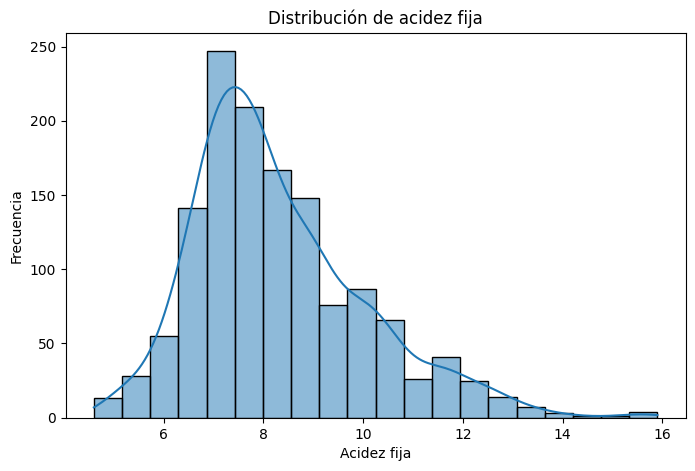

In [77]:
plt.figure(figsize=(8,5))
sns.histplot(df_e['acidez_fija'],
                bins=20,              # divide los datos en 20 intervalos
                kde=True)             # kde=True añade la curva de densidad
    
plt.title(f'Distribución de {'acidez fija'}')
plt.xlabel('Acidez fija')
plt.ylabel('Frecuencia')
         
plt.savefig('img/Distr_acidez_fija.png')   
plt.show()



En el histograma se observa:

- La mayoría de valores se concentra entre 6 y 9.
- Existe una cola hacia la derecha.
- Algunos valores alcanzan niveles altos cercanos a 16.

Interpretación:

La variable presenta una distribución ligeramente asimétrica positiva. La mayor parte de los vinos posee niveles moderados de acidez fija, aunque existen pocos vinos con valores considerablemente elevados.

El siguiente boxplot representa la distribución de la variable “acidez fija” en el dataset de vinos:

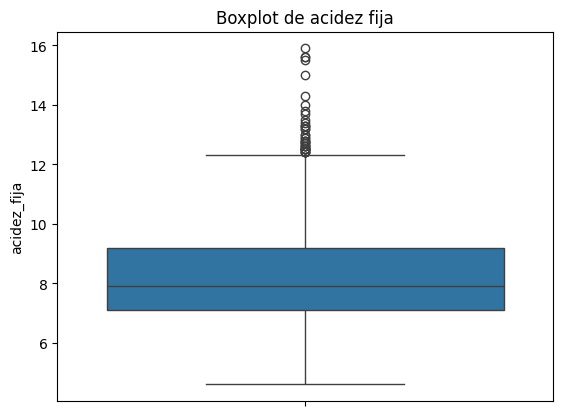

In [78]:
#plt.figure(figsize=(6,4))
sns.boxplot(y=df_e['acidez_fija'])

plt.title(f'Boxplot de {'acidez fija'}')

plt.savefig('img/Boxplot_acidez_fija.png') 
plt.show()

Observando el gráfico del boxplot: 
- La mediana se encuentra aproximadamente entre 7 y 8.
- La mayoría de valores están relativamente concentrados.
- Existen numerosos outliers superiores por encima de 12.

Interpretación:

La variable presenta una distribución ligeramente asimétrica positiva, ya que aparecen varios valores altos alejados del resto de observaciones. La mayoría de vinos tienen niveles moderados de acidez fija, aunque algunos presentan concentraciones considerablemente elevadas.

#### 4.1.2 VARIABLE  $\Rightarrow$  volatile acidity  &rarr;  acidez volátil

In [79]:
df_e["acidez_volatil"].value_counts()

acidez_volatil
0.500    37
0.580    36
0.400    35
0.600    34
0.430    33
         ..
0.955     1
1.580     1
1.180     1
0.475     1
0.895     1
Name: count, Length: 143, dtype: int64

In [80]:
# Valor minimo de la acidez volátil
ac_v_min = df_e['acidez_volatil'].min()
print(f"Valor mínimo de la acidez fija: {ac_v_min}")

# Valor maximo de la acidez volátil
ac_v_max = df_e['acidez_volatil'].max()
print(f"Valor máximo de la acidez fija: {ac_v_max}")

Valor mínimo de la acidez fija: 0.12
Valor máximo de la acidez fija: 1.58


Histograma de la variable acidez volátil:

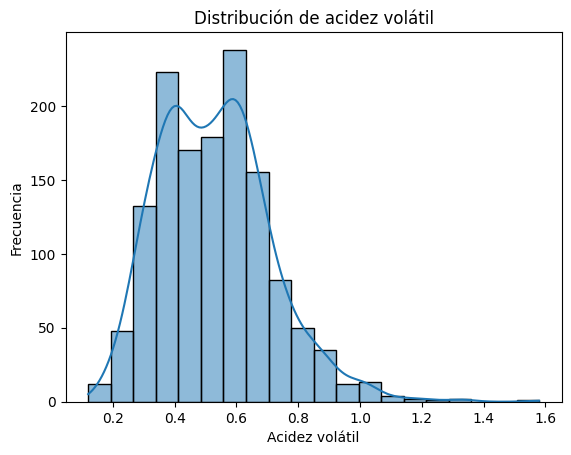

In [81]:
# plt.figure(figsize=(8,5))

sns.histplot(df_e['acidez_volatil'],
                bins=20,             # divide los datos en 20 intervalos
                kde=True)            # kde=True añade la curva de densidad
    
plt.title(f'Distribución de {'acidez volátil'}')
plt.xlabel('Acidez volátil')
plt.ylabel('Frecuencia')
         
plt.savefig('img/Distr_acidez_volatil.png')     
plt.show()

En el histograma se observa:

- Los datos se concentran entre 0.3 y 0.7.
- Existe una cola hacia valores altos.
- Hay pocos valores extremos superiores a 1.

Interpretación:

La distribución presenta asimetría positiva. La mayoría de vinos tiene niveles moderados de acidez volátil, mientras que algunos vinos presentan concentraciones altas que podrían afectar negativamente la calidad.

El siguiente boxplot representa la distribución de la variable “ácido volátil” en el dataset de vinos:

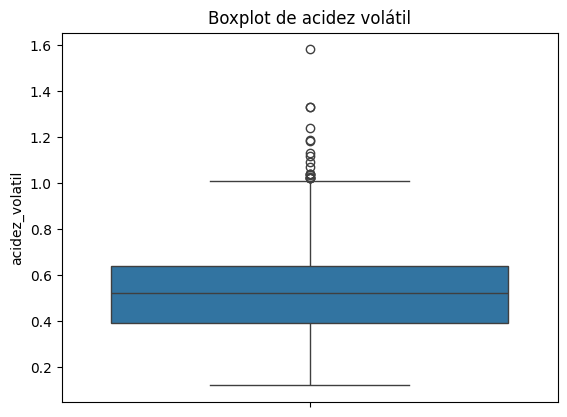

In [82]:
#plt.figure(figsize=(6,4))
sns.boxplot(y=df_e['acidez_volatil'])

plt.title(f'Boxplot de {'acidez volátil'}')

plt.savefig('img/Boxplot_acidez_volatil.png') 
plt.show()

Observando el gráfico del boxplot:

- La mediana está cerca de 0.5.
- Se observan varios outliers superiores.
- Existe una cola superior más extensa.

Interpretación:

La distribución presenta asimetría positiva. La mayoría de vinos tienen niveles moderados de acidez volátil, pero algunos vinos muestran valores elevados que podrían afectar negativamente la calidad del vino.

#### 4.1.3 VARIABLE  $\Rightarrow$   citric acid  &rarr;  ácido cítrico

In [83]:
df_e["acido_citrico"].value_counts()

acido_citrico
0.00    118
0.49     59
0.24     41
0.02     38
0.08     32
       ... 
0.79      1
0.71      1
0.72      1
0.75      1
0.78      1
Name: count, Length: 80, dtype: int64

In [84]:
# Valor minimo del acido cítrico
citrico_min = df_e['acido_citrico'].min()
print(f"Valor mínimo de la acidez fija: {citrico_min}")

# Valor máximo del acido cítrico
citrico_max = df_e['acido_citrico'].max()
print(f"Valor máximo del acido cítrico: {citrico_max}")

Valor mínimo de la acidez fija: 0.0
Valor máximo del acido cítrico: 1.0


Histograma de la variable ácido cítrico:

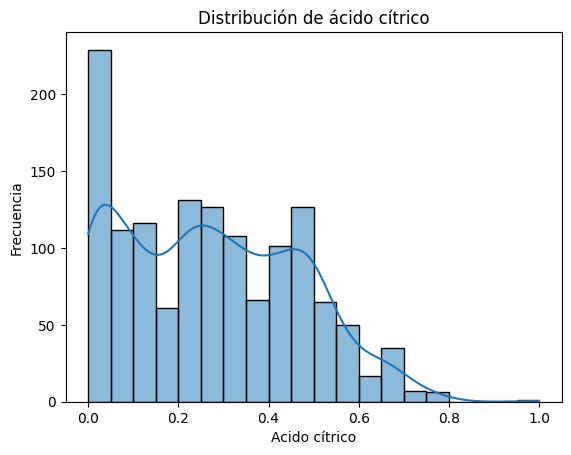

In [85]:
# plt.figure(figsize=(8,5))

sns.histplot(df_e['acido_citrico'],
                bins=20,             # divide los datos en 20 intervalos
                kde=True)            # kde=True añade la curva de densidad
    
plt.title(f'Distribución de {'ácido cítrico'}')
plt.xlabel('Acido cítrico')
plt.ylabel('Frecuencia')
         
plt.savefig('img/Distr_ac_citrico.png')     
plt.show()

En el histograma se observa:

- Gran concentración de valores bajos.
- Distribución relativamente dispersa.
- Pocos valores superiores a 0.8.

Interpretación:

La variable muestra una ligera asimetría positiva. La mayoría de vinos contiene cantidades bajas o moderadas de ácido cítrico.

El siguiente boxplot representa la distribución de la variable “ácido cítrico” en el dataset de vinos:

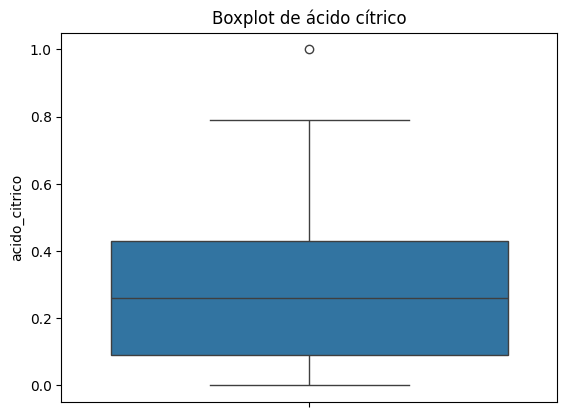

In [86]:
#plt.figure(figsize=(6,4))
sns.boxplot(y=df_e['acido_citrico'])

plt.title(f'Boxplot de {'ácido cítrico'}')

plt.savefig('img/Boxplot_ac_citrico.png') 
plt.show()

Observando el gráfico del boxplot:

- La mediana ronda 0.25.
- La distribución parece relativamente equilibrada.
- Existen pocos outliers altos.

Interpretación:

La variable presenta una distribución más estable respecto a otras variables. La mayoría de observaciones se concentra entre valores bajos y moderados de ácido cítrico, con pocos valores extremos.

#### 4.1.4 VARIABLE  $\Rightarrow$   residual sugar  &rarr;  azúcar residual

In [87]:
df_e["azucar_resid"].value_counts()

azucar_resid
2.00     133
2.20     110
1.80     108
2.10     104
1.90      97
        ... 
15.40      1
3.75       1
13.80      1
5.70       1
13.90      1
Name: count, Length: 91, dtype: int64

In [88]:
# Valor minimo del azúcar
azucar_min = df_e['azucar_resid'].min()
print(f"Valor mínimo del azúcar: {azucar_min}")

# Valor máximo del azúcar
azucar_max = df_e['azucar_resid'].max()
print(f"Valor máximo del azúcar: {azucar_max}")

Valor mínimo del azúcar: 0.9
Valor máximo del azúcar: 15.5


Histograma de la variable azúcar residual:

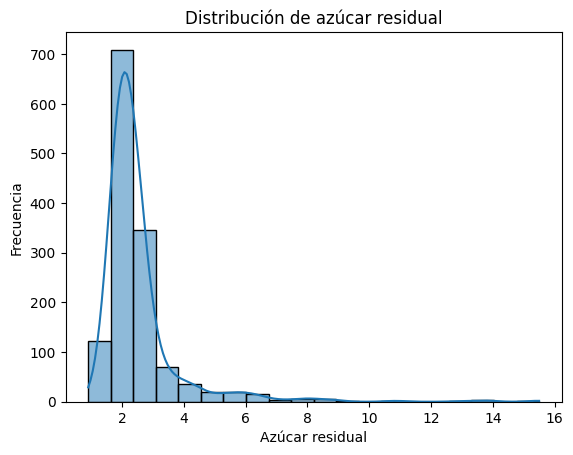

In [89]:
# plt.figure(figsize=(8,5))

sns.histplot(df_e['azucar_resid'],
                bins=20,             # divide los datos en 20 intervalos
                kde=True)            # kde=True añade la curva de densidad
    
plt.title(f'Distribución de {'azúcar residual'}')
plt.xlabel('Azúcar residual')
plt.ylabel('Frecuencia')
         
plt.savefig('img/Distr_azucar_resid.png')     
plt.show()

En el histograma se observa:

- La mayoría de datos se concentra entre 1 y 3.
- Existe una cola larga hacia la derecha.
. Aparecen valores altos cercanos a 16.

Interpretación:

La distribución es fuertemente asimétrica positiva. La mayoría de vinos contiene poco azúcar residual, aunque algunos presentan concentraciones significativamente mayores.

El siguiente boxplot representa la distribución de la variable “azúcar residual” en el dataset de vinos:

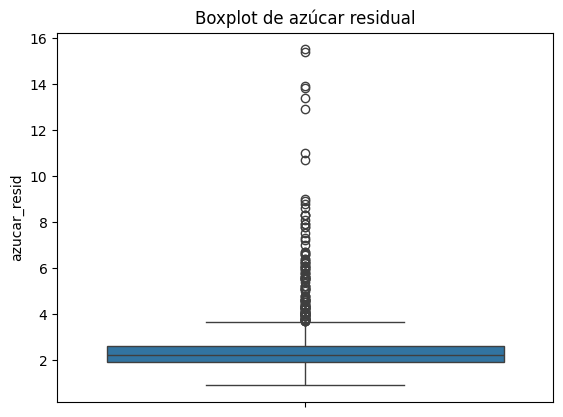

In [90]:
#plt.figure(figsize=(6,4))
sns.boxplot(y=df_e['azucar_resid'])

plt.title(f'Boxplot de {'azúcar residual'}')

plt.savefig('img/Boxplot_azucar_resid.png') 
plt.show()

Observando el gráfico del boxplot:


- La caja está muy concentrada en valores bajos.
- Existen numerosos outliers superiores.
- Algunos valores superan ampliamente el rango principal.

Interpretación:

La variable presenta una fuerte asimetría positiva. La mayoría de vinos contienen bajos niveles de azúcar residual, aunque algunos vinos presentan cantidades considerablemente altas.

#### 4.1.5 VARIABLE  $\Rightarrow$   chlorides  &rarr;  cloruros

In [91]:
df_e["cloruros"].value_counts()

cloruros
0.080    50
0.078    44
0.074    43
0.084    40
0.076    39
         ..
0.267     1
0.169     1
0.205     1
0.235     1
0.230     1
Name: count, Length: 153, dtype: int64

In [92]:
# Valor minimo de los cloruros
cloruro_min = df_e['cloruros'].min()
print(f"Valor mínimo del cloruro: {cloruro_min}")

# Valor máximo del azúcar
cloruro_max = df_e['cloruros'].max()
print(f"Valor máximo del cloruro: {cloruro_max}")

Valor mínimo del cloruro: 0.012
Valor máximo del cloruro: 0.611


Histograma de la variable cloruros:

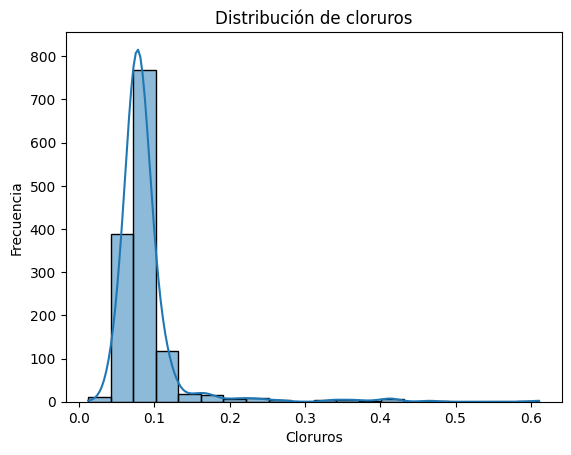

In [93]:
# plt.figure(figsize=(8,5))

sns.histplot(df_e['cloruros'],
                bins=20,             # divide los datos en 20 intervalos
                kde=True)            # kde=True añade la curva de densidad
    
plt.title(f'Distribución de {'cloruros'}')
plt.xlabel('Cloruros')
plt.ylabel('Frecuencia')
         
plt.savefig('img/Distr_cloruros.png')     
plt.show()

En el histograma se observa:
- Gran concentración alrededor de 0.07–0.10.
- Cola extensa hacia valores altos.
- Existen pocos valores extremos cercanos a 0.6.

Interpretación:

La variable presenta una fuerte asimetría positiva y posibles outliers. La mayoría de vinos tiene niveles bajos de cloruros.

El siguiente boxplot representa la distribución de la variable “cloruros” en el dataset de vinos:

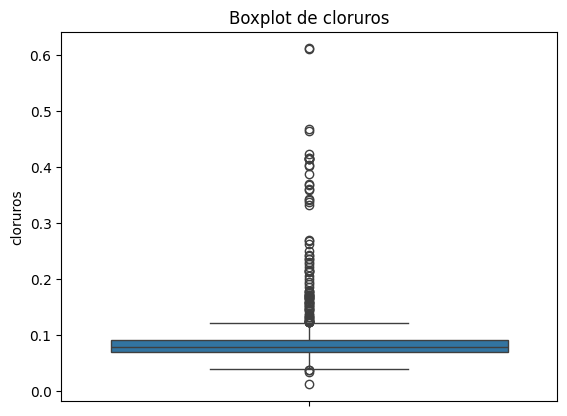

In [94]:
#plt.figure(figsize=(6,4))
sns.boxplot(y=df_e['cloruros'])

plt.title(f'Boxplot de {'cloruros'}')

plt.savefig('img/Boxplot_cloruros.png') 
plt.show()

Observando el gráfico del boxplot:


- La mayoría de datos se concentra en valores pequeños.
- Existen múltiples outliers altos.
- La cola superior es extensa.

Interpretación:

La variable muestra una distribución muy sesgada hacia la derecha. Aunque la mayoría de vinos tiene niveles bajos de cloruros, existen vinos con concentraciones anormalmente altas.

#### 4.1.6 VARIABLE  $\Rightarrow$   free sulfur dioxide  &rarr;  dióxido de azufre libre

In [95]:
df_e["dioxido_azufre_libre"].value_counts()

dioxido_azufre_libre
6.0     121
5.0      88
15.0     65
12.0     64
10.0     63
7.0      61
9.0      55
16.0     53
17.0     50
11.0     49
13.0     48
8.0      47
14.0     41
3.0      41
18.0     40
21.0     36
4.0      34
19.0     34
26.0     29
23.0     28
24.0     27
20.0     26
27.0     24
25.0     21
28.0     20
29.0     19
22.0     19
32.0     19
34.0     17
35.0     14
31.0     14
30.0     13
33.0     10
36.0      9
38.0      7
40.0      5
41.0      5
39.0      4
52.0      3
51.0      3
42.0      3
37.0      3
43.0      3
45.0      3
48.0      3
50.0      2
1.0       2
37.5      2
40.5      1
68.0      1
47.0      1
54.0      1
46.0      1
2.0       1
5.5       1
53.0      1
57.0      1
72.0      1
55.0      1
66.0      1
Name: count, dtype: int64

In [96]:
# Valor minimo del dioxido de azufre libre
d_s_l_min = df_e['dioxido_azufre_libre'].min()
print(f"Valor mínimo del dioxido de azufre libre: {d_s_l_min}")

# Valor máximo del dioxido de azufre libre
d_s_l_max = df_e['dioxido_azufre_libre'].max()
print(f"Valor máximo del dioxido de azufre libre: {d_s_l_max}")

Valor mínimo del dioxido de azufre libre: 1.0
Valor máximo del dioxido de azufre libre: 72.0


Histograma de la variable dióxido de azufre libre:

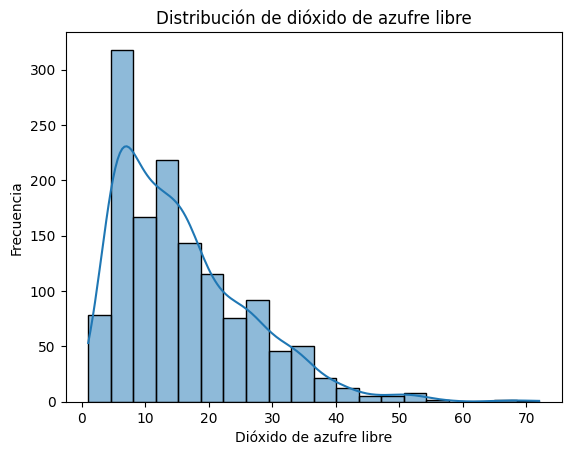

In [97]:
# plt.figure(figsize=(8,5))

sns.histplot(df_e['dioxido_azufre_libre'],
                bins=20,             # divide los datos en 20 intervalos
                kde=True)            # kde=True añade la curva de densidad
    
plt.title(f'Distribución de {'dióxido de azufre libre'}')
plt.xlabel('Dióxido de azufre libre')
plt.ylabel('Frecuencia')
         
plt.savefig('img/Distr_dioxido_azufre_libre.png')     
plt.show()

En el histograma se observa:

- La mayoría de observaciones se encuentra entre 5 y 25.
- La frecuencia disminuye progresivamente hacia valores altos.
- Existen algunos valores extremos.

Interpretación:

La distribución presenta asimetría positiva moderada. La mayoría de vinos tiene concentraciones bajas o moderadas de dióxido de azufre libre.

El siguiente boxplot representa la distribución de la variable “dióxido de azufre libre” en el dataset de vinos:

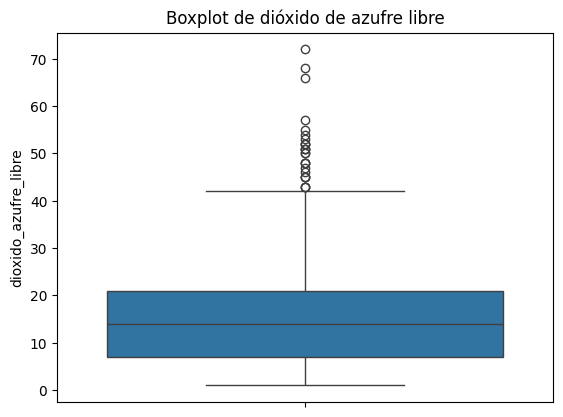

In [98]:
#plt.figure(figsize=(6,4))
sns.boxplot(y=df_e['dioxido_azufre_libre'])

plt.title(f'Boxplot de {'dióxido de azufre libre'}')

plt.savefig('img/Boxplot_dioxido_azufre_libre.png') 
plt.show()

Observando el gráfico del boxplot:


- Mediana cercana a 14.
- Presencia de numerosos outliers superiores.
- Amplia dispersión.

Interpretación:

La variable presenta asimetría positiva y valores extremos elevados. Esto indica que algunos vinos contienen concentraciones significativamente mayores de dióxido de azufre libre respecto a la mayoría.

#### 4.1.7 VARIABLE  $\Rightarrow$   total sulfur dioxide  &rarr;  dióxido de azufre total

In [99]:
df_e["dioxido_azufre_total"].value_counts()

dioxido_azufre_total
28.0     35
24.0     32
14.0     30
20.0     29
18.0     28
         ..
278.0     1
289.0     1
160.0     1
77.5      1
131.0     1
Name: count, Length: 144, dtype: int64

In [100]:
# Valor minimo del dioxido de azufre total
d_s_t_min = df_e['dioxido_azufre_total'].min()
print(f"Valor mínimo del dioxido de azufre total: {d_s_t_min}")

# Valor máximo del dioxido de azufre total
d_s_t_max = df_e['dioxido_azufre_total'].max()
print(f"Valor máximo del dioxido de azufre total: {d_s_t_max}")

Valor mínimo del dioxido de azufre total: 6.0
Valor máximo del dioxido de azufre total: 289.0


Histograma de la variable dióxido de azufre total:

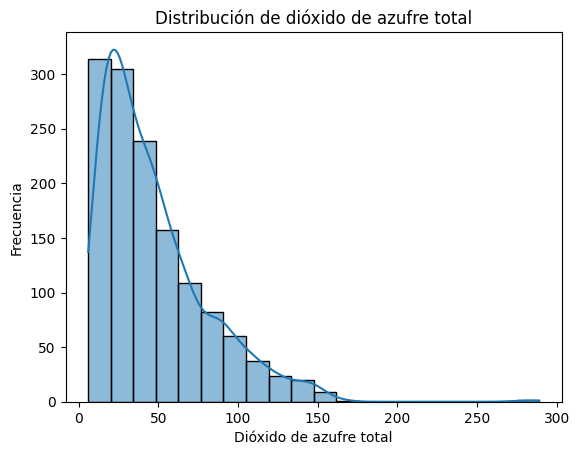

In [101]:
# plt.figure(figsize=(8,5))

sns.histplot(df_e['dioxido_azufre_total'],
                bins=20,             # divide los datos en 20 intervalos
                kde=True)            # kde=True añade la curva de densidad
    
plt.title(f'Distribución de {'dióxido de azufre total'}')
plt.xlabel('Dióxido de azufre total')
plt.ylabel('Frecuencia')
         
plt.savefig('img/Distr_dioxido_azufre_total.png')    
plt.show()

En el histograma se observa:

- Alta concentración en valores bajos.
- Cola muy larga hacia la derecha.
- Algunos valores alcanzan casi 300.

Interpretación:

La variable muestra una marcada asimetría positiva y presencia de valores extremos. Algunos vinos poseen cantidades muy elevadas de dióxido de azufre total respecto al resto.

El siguiente boxplot representa la distribución de la variable “dióxido de azufre total” en el dataset de vinos:

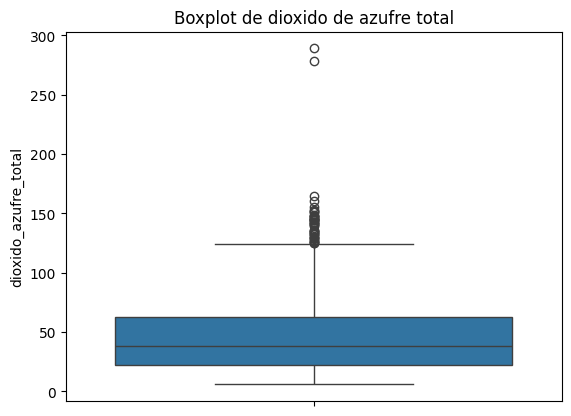

In [102]:
#plt.figure(figsize=(6,4))
sns.boxplot(y=df_e['dioxido_azufre_total'])

plt.title(f'Boxplot de {'dioxido de azufre total'}')

plt.savefig('img/Boxplot_dioxido_azufre_total.png') 
plt.show()



Observando el gráfico del boxplot:

- La mediana se encuentra alrededor de 38.
- Se observan muchos outliers altos.
- Existen valores extremadamente elevados cercanos a 300.

Interpretación:

La distribución es claramente asimétrica positiva. La mayoría de vinos presenta niveles moderados, mientras que algunos contienen cantidades excepcionalmente altas de dióxido de azufre total.


#### 4.1.8 VARIABLE  $\Rightarrow$   density  &rarr;  densidad


In [103]:
df_e["densidad"].value_counts()

densidad
0.99680    33
0.99760    30
0.99720    29
0.99800    28
0.99620    23
           ..
0.99474     1
0.99483     1
0.99314     1
0.99574     1
0.99651     1
Name: count, Length: 436, dtype: int64

In [104]:
# Valor minimo de la densidad
densidad_min = df_e['densidad'].min()
print(f"Valor mínimo de la densidad: {densidad_min}")

# Valor máximo del azúcar
densidad_max = df_e['densidad'].max()
print(f"Valor máximo de la densidad: {densidad_max}")

Valor mínimo de la densidad: 0.99007
Valor máximo de la densidad: 1.00369


Histograma de la variable densidad:

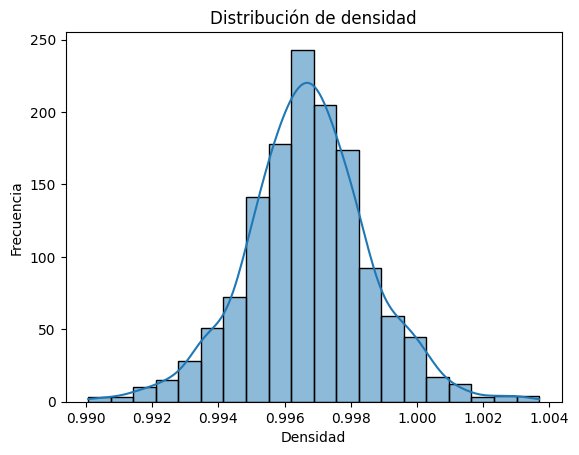

In [105]:
# plt.figure(figsize=(8,5))

sns.histplot(df_e['densidad'],
                bins=20,             # divide los datos en 20 intervalos
                kde=True)            # kde=True añade la curva de densidad
    
plt.title(f'Distribución de {'densidad'}')
plt.xlabel('Densidad')
plt.ylabel('Frecuencia')
         
plt.savefig('img/Distr_densidad.png')     
plt.show()

En el histograma se observa:
- Distribución con forma aproximadamente normal.
- Datos concentrados alrededor de 0.996–0.997.
- Baja dispersión.

Interpretación:

La variable presenta una distribución relativamente simétrica y estable. La mayoría de vinos posee densidades similares.

El siguiente boxplot representa la distribución de la variable “densidad” en el dataset de vinos:

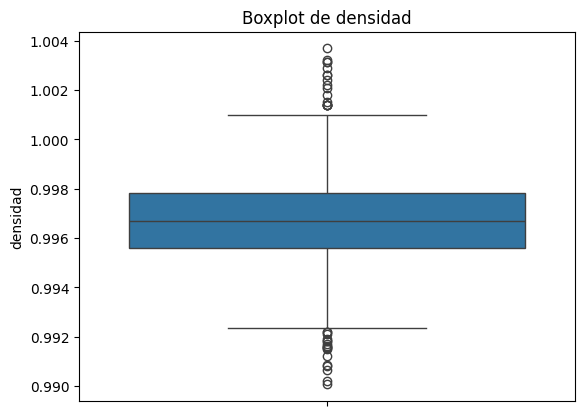

In [106]:
#plt.figure(figsize=(6,4))
sns.boxplot(y=df_e['densidad'])

plt.title(f'Boxplot de {'densidad'}')

plt.savefig('img/Boxplot_densidad.png') 
plt.show()

Observando el gráfico del boxplot:


- La caja es pequeña y compacta.
- Baja dispersión.
- Algunos outliers tanto superiores como inferiores.

Interpretación:

La densidad presenta una distribución relativamente estable y poco variable. La mayoría de observaciones están muy concentradas alrededor de la media.

#### 4.1.9 VARIABLE  $\Rightarrow$   pH

In [107]:
df_e["pH"].value_counts()

pH
3.30    47
3.26    45
3.36    42
3.38    41
3.34    40
        ..
2.86     1
3.74     1
2.87     1
3.70     1
2.90     1
Name: count, Length: 89, dtype: int64

In [108]:
# Valor minimo del pH
pH_min = df_e['pH'].min()
print(f"Valor mínimo del pH: {pH_min}")

# Valor máximo del pH
pH_max = df_e['pH'].max()
print(f"Valor máximo del pH: {pH_max}")

Valor mínimo del pH: 2.74
Valor máximo del pH: 4.01


Histograma de la variable pH:

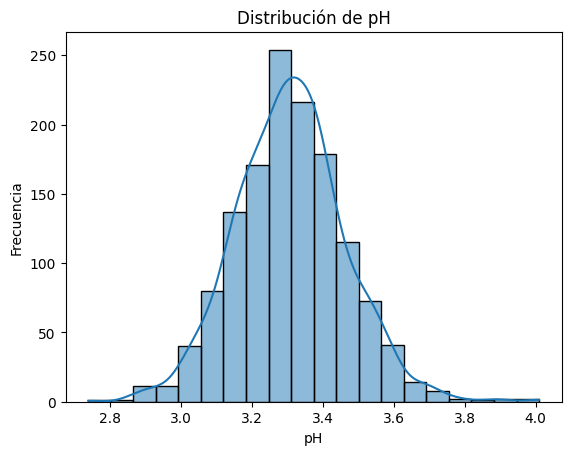

In [109]:
# plt.figure(figsize=(8,5))

sns.histplot(df_e['pH'],
                bins=20,             # divide los datos en 20 intervalos
                kde=True)            # kde=True añade la curva de densidad
    
plt.title(f'Distribución de {'pH'}')
plt.xlabel('pH')
plt.ylabel('Frecuencia')
         
plt.savefig('img/Distr_pH.png')     
plt.show()

En el histograma se observa:

- Distribución aproximadamente simétrica.
- Mayor concentración entre 3.2 y 3.4.
- Pocos valores extremos.

Interpretación:

La variable sigue una distribución cercana a la normal. Los niveles de pH son bastante consistentes entre los vinos.

El siguiente boxplot representa la distribución de la variable “pH” en el dataset de vinos:

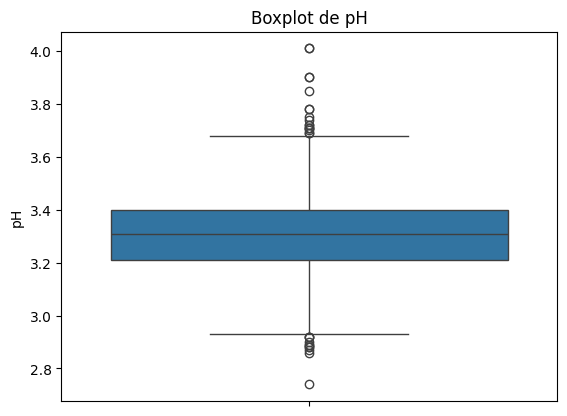

In [110]:
#plt.figure(figsize=(6,4))
sns.boxplot(y=df_e['pH'])

plt.title(f'Boxplot de {'pH'}')

plt.savefig('img/Boxplot_pH.png') 
plt.show()

Observando el gráfico del boxplot:


- Distribución bastante equilibrada.
- Mediana cercana a 3.3.
- Pocos outliers.

Interpretación:

La variable presenta una distribución relativamente simétrica y estable. La mayoría de vinos mantiene niveles similares de pH.

#### 4.1.10 VARIABLE  $\Rightarrow$   sulphates  &rarr;  sulfatos

In [111]:
df_e["sulfatos"].value_counts()

sulfatos
0.54    58
0.58    57
0.60    57
0.62    53
0.56    52
        ..
1.34     1
1.16     1
1.15     1
1.33     1
1.01     1
Name: count, Length: 96, dtype: int64

In [112]:
# Valor minimo de los sulfatos
sulfatos_min = df_e['sulfatos'].min()
print(f"Valor mínimo de los sulfatos: {sulfatos_min}")

# Valor máximo de los sulfatos
sulfatos_max = df_e['sulfatos'].max()
print(f"Valor máximo de los sulfatos: {sulfatos_max}")

Valor mínimo de los sulfatos: 0.33
Valor máximo de los sulfatos: 2.0


Histograma de la variable sulfatos:

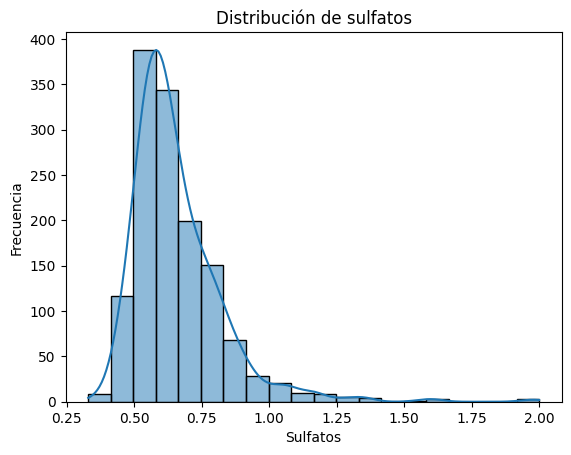

In [113]:
# plt.figure(figsize=(8,5))

sns.histplot(df_e['sulfatos'],
                bins=20,             # divide los datos en 20 intervalos
                kde=True)            # kde=True añade la curva de densidad
    
plt.title(f'Distribución de {'sulfatos'}')
plt.xlabel('Sulfatos')
plt.ylabel('Frecuencia')
         
plt.savefig('img/Distr_sulfatos.png')     
plt.show()

En el histograma se observa:

- Concentración principal entre 0.5 y 0.8.
- Cola hacia valores altos.
- Algunos valores cercanos a 2.

Interpretación:

La distribución presenta asimetría positiva. Aunque la mayoría de vinos contiene niveles moderados de sulfatos, algunos presentan concentraciones considerablemente altas.

El siguiente boxplot representa la distribución de la variable “sulfatos” en el dataset de vinos:

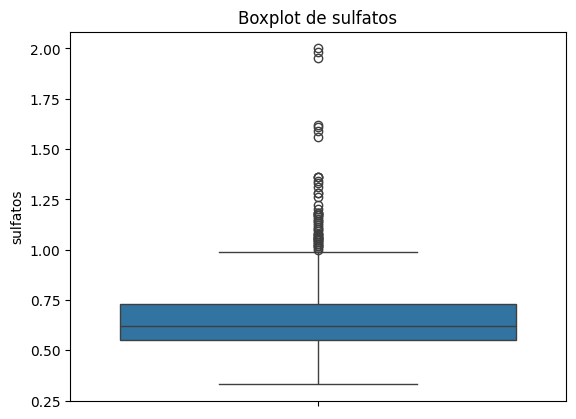

In [114]:
#plt.figure(figsize=(6,4))
sns.boxplot(y=df_e['sulfatos'])

plt.title(f'Boxplot de {'sulfatos'}')

plt.savefig('img/Boxplot_sulfatos.png') 
plt.show()

Observando el gráfico del boxplot:


- Concentración principal entre 0.5 y 0.7.
- Numerosos outliers superiores.
- Algunos valores cercanos a 2.

Interpretación:

La variable presenta asimetría positiva y valores atípicos altos. Algunos vinos contienen concentraciones elevadas de sulphates respecto a la mayoría del dataset.

#### 4.1.11 VARIABLE  $\Rightarrow$   alcohol

In [116]:
df_e["alcohol"].value_counts()

alcohol
9.500000     111
9.400000      91
9.200000      65
9.800000      63
10.000000     61
            ... 
9.950000       1
9.233333       1
9.250000       1
9.050000       1
10.750000      1
Name: count, Length: 65, dtype: int64

In [117]:
# Valor minimo del alcohol
alcohol_min = df_e['alcohol'].min()
print(f"Valor mínimo del alcohol: {alcohol_min}")

# Valor máximo del alcohol
alcohol_max = df_e['alcohol'].max()
print(f"Valor máximo del alcohol: {alcohol_max}")

Valor mínimo del alcohol: 8.4
Valor máximo del alcohol: 14.9


Histograma de la variable alcohol:

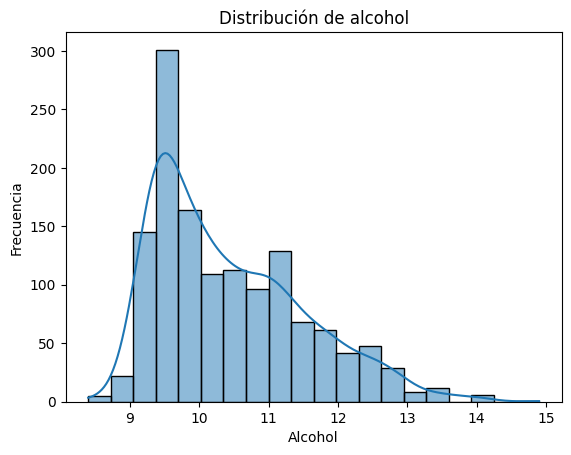

In [118]:
# plt.figure(figsize=(8,5))

sns.histplot(df_e['alcohol'],
                bins=20,             # divide los datos en 20 intervalos
                kde=True)            # kde=True añade la curva de densidad
    
plt.title(f'Distribución de {'alcohol'}')
plt.xlabel('Alcohol')
plt.ylabel('Frecuencia')
         
plt.savefig('img/Distr_alcohol.png')     
plt.show()

En el histograma se observa:

- Mayor concentración entre 9 y 11 grados.
- Cola hacia la derecha.
- Existen algunos vinos con niveles superiores a 14.

Interpretación:

La variable presenta ligera asimetría positiva. La mayoría de vinos posee niveles moderados de alcohol, aunque algunos alcanzan concentraciones elevadas.

El siguiente boxplot representa la distribución de la variable “alcohol” en el dataset de vinos:

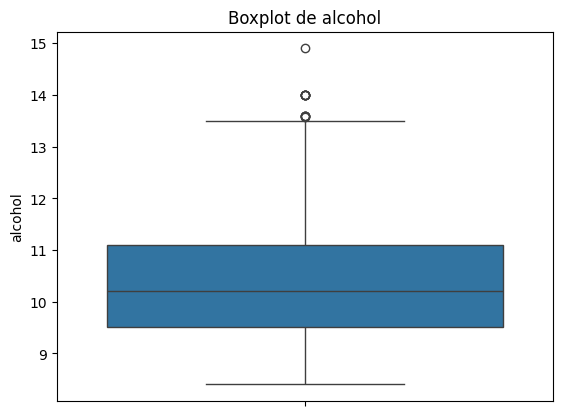

In [119]:
#plt.figure(figsize=(6,4))
sns.boxplot(y=df_e['alcohol'])

plt.title(f'Boxplot de {'alcohol'}')

plt.savefig('img/Boxplot_alcohol.png') 
plt.show()

Observando el gráfico del boxplot:


- Mediana cercana a 10.
- Distribución relativamente equilibrada.
- Algunos outliers altos próximos a 15.

Interpretación:

La variable presenta dispersión moderada y ligera asimetría positiva. La mayoría de vinos posee niveles de alcohol entre 9 y 11, aunque algunos vinos alcanzan valores considerablemente mayores.

#### 4.1.12 VARIABLE  $\Rightarrow$   quality  &rarr;  calidad 

In [120]:
df_e["calidad"].value_counts()

calidad
5    577
6    535
7    167
4     53
8     17
3     10
Name: count, dtype: int64

Ordenamos por la calidad

In [121]:
calidad_counts = (
    df_e["calidad"]
    .value_counts()
    .sort_index()
    .reset_index()
)

calidad_counts.columns = ["Calidad", "Frecuencia"]

print(calidad_counts.to_string(index=False))

 Calidad  Frecuencia
       3          10
       4          53
       5         577
       6         535
       7         167
       8          17


In [122]:
# Valor minimo de la calidad
calidad_min = df_e['calidad'].min()
print(f"Valor mínimo de la calidad: {calidad_min}")

# Valor máximo de la calidad
calidad_max = df_e['calidad'].max()
print(f"Valor máximo de la calidad: {calidad_max}")

Valor mínimo de la calidad: 3
Valor máximo de la calidad: 8


Distribución de la variable calidad:

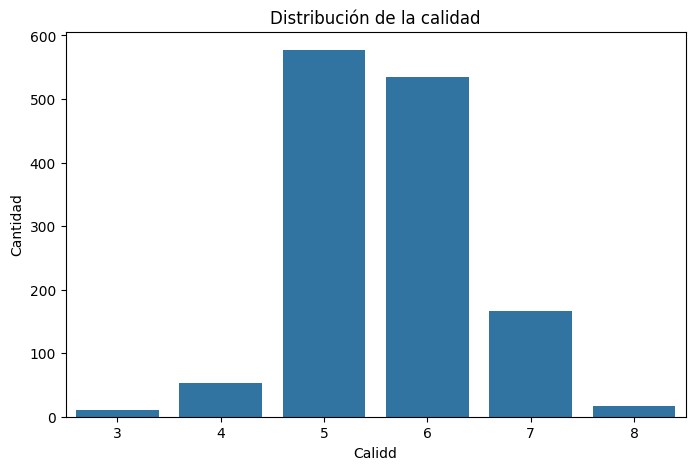

In [123]:
plt.figure(figsize=(8,5))

sns.countplot(x='calidad', data=df_e)

plt.title('Distribución de la calidad')
plt.xlabel('Calidd')
plt.ylabel('Cantidad')

plt.savefig('img/Distr_calidad.png') 
plt.show()

Se observa:

La mayoría de vinos tiene calidad 5 o 6.
Muy pocos vinos presentan calidad extrema (3 u 8).
Distribución discreta.

Interpretación:


La variable objetivo presenta un ligero desbalance de clases, ya que predominan vinos de calidad media. Esto será importante durante el entrenamiento de modelos de Machine Learning.

#### 4.1.13 RESUMEN GRAFICOS DE LAS VARIABLES

Se representan todas las distribuciones de las variables en un solo gráfico:


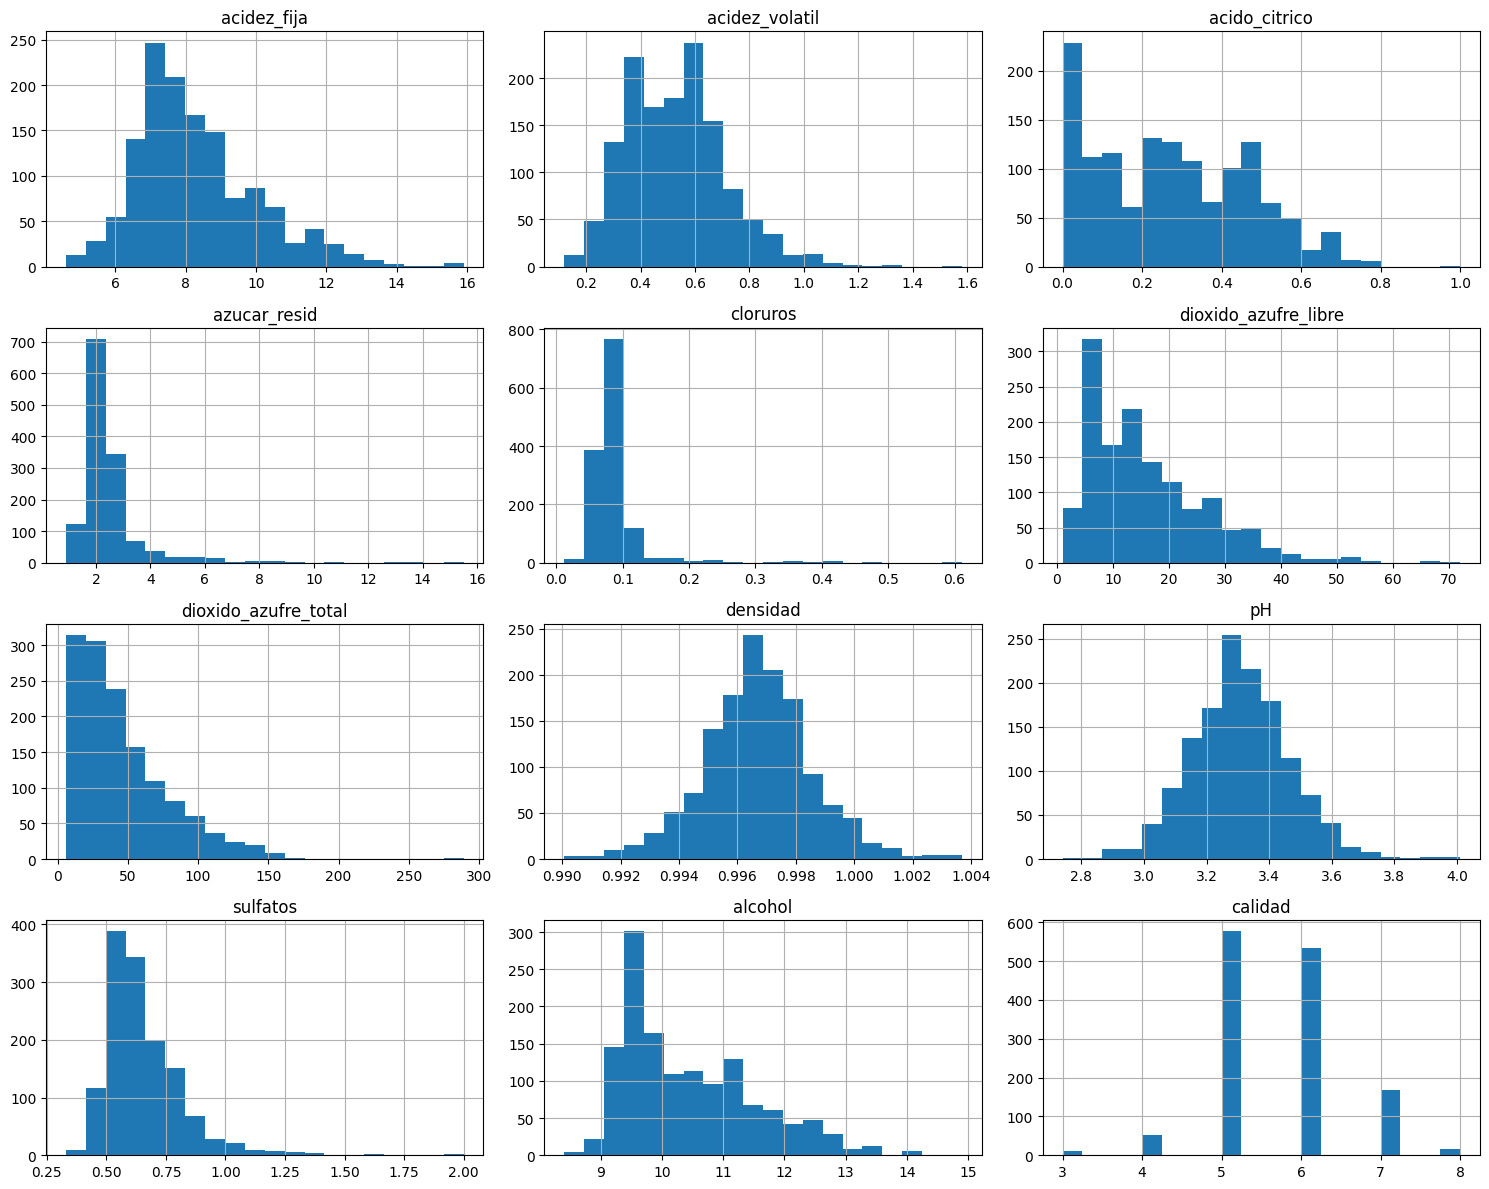

In [126]:
df_e.hist(bins=20, figsize=(15,12)) 
plt.tight_layout() 

plt.savefig('img/Distribucion_todas_variables.png') 
plt.show()

Se representan todos los Boxplot de las variables en un solo gráfico:

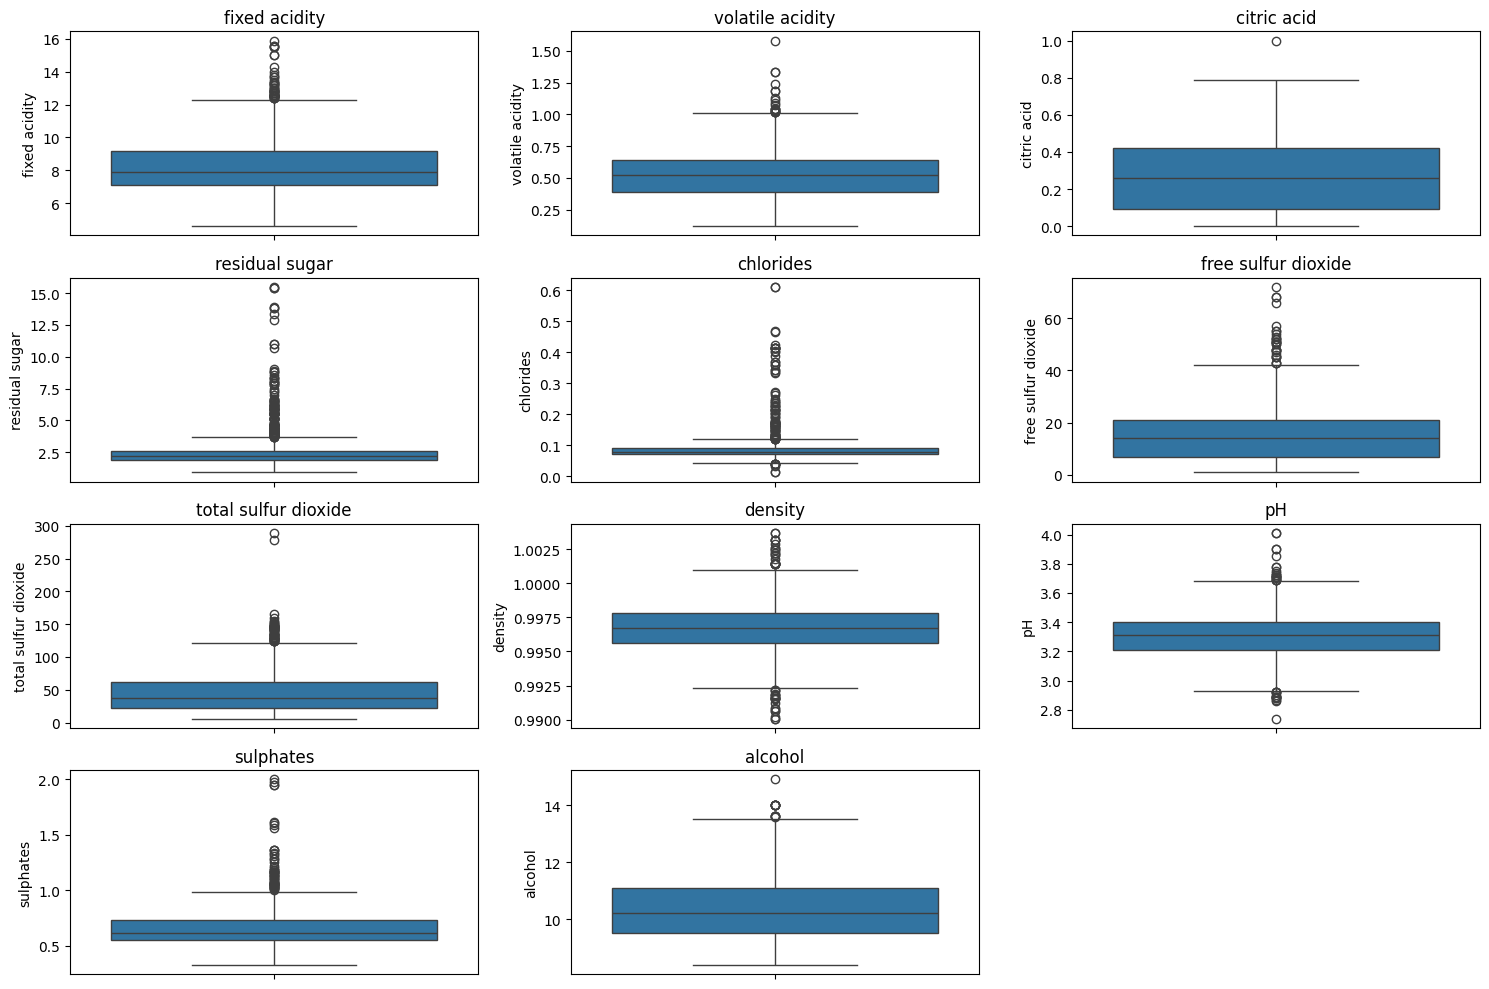

In [127]:
plt.figure(figsize=(15,10))

for i, column in enumerate(df.columns[:-1], 1):
    plt.subplot(4,3,i)
    sns.boxplot(y=df[column])
    plt.title(column)

plt.tight_layout()

plt.savefig('img/Boxplot_todas_variables.png') 
plt.show()

In [32]:
df_e = pd.read_csv ("data_new/df_e.csv")

### 4.2 ANALISIS BIVARIADO

#### 4.2.1 RELACION ENTRE LAS VARIABLES

Ahora se va a explorar visualmente las relaciones entre todas las variables numéricas del dataset al mismo tiempo.

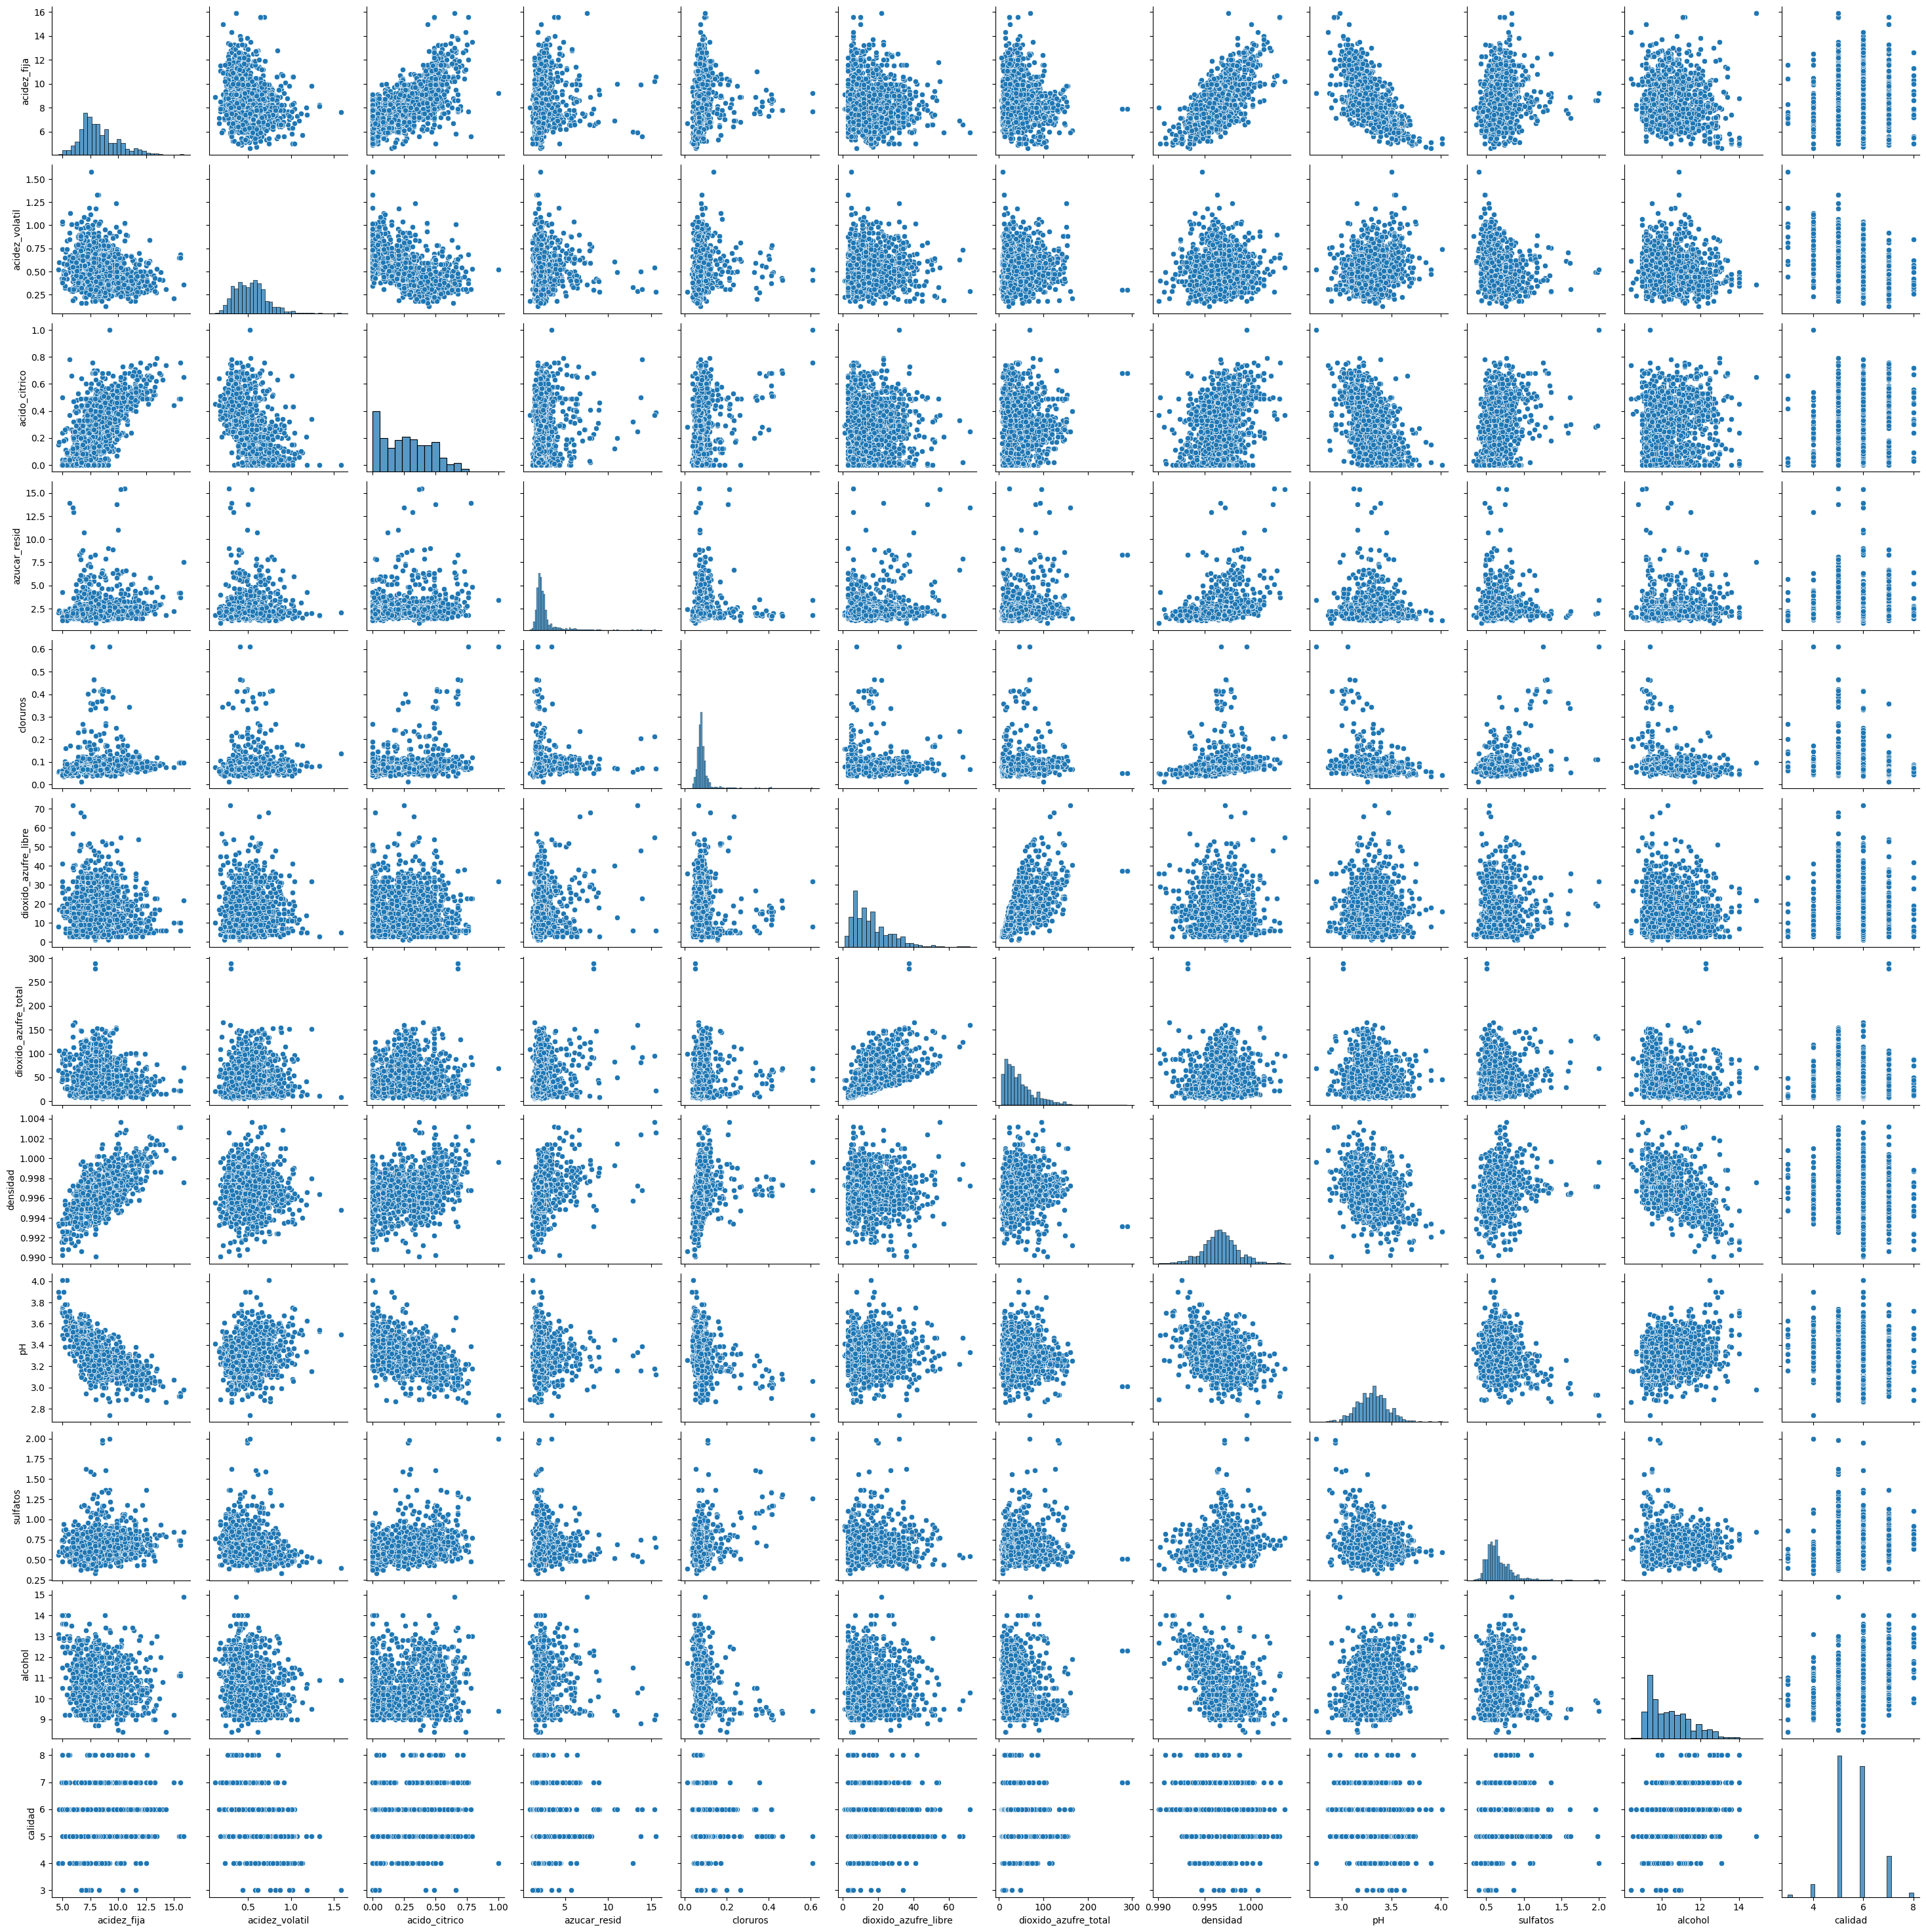

In [ ]:
sns.pairplot(df_e)


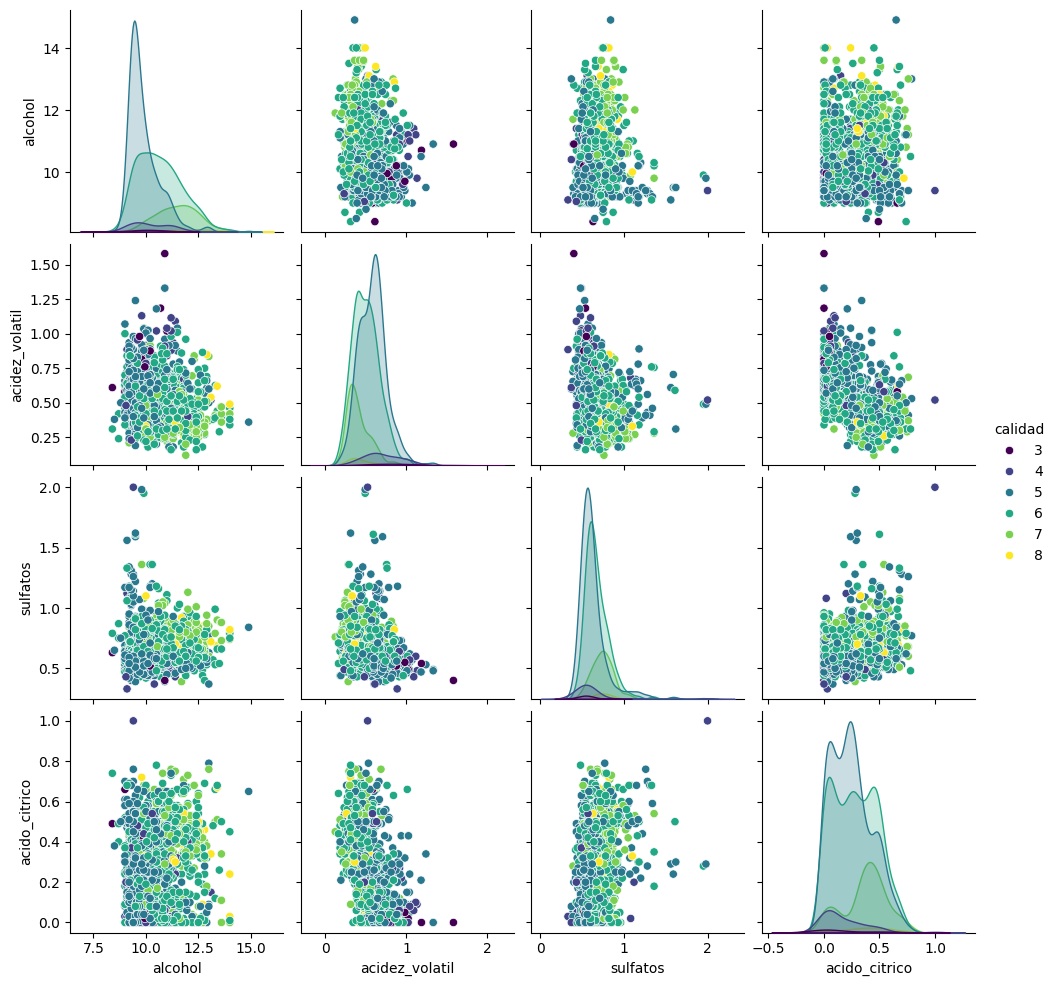

In [34]:
# Pairplot de variables importantes
vbles_imp = [
    'alcohol',
    'acidez_volatil',
    'sulfatos',
    'acido_citrico',
    'calidad'
]

sns.pairplot(df_e[vbles_imp],
             hue='calidad',
             palette='viridis' )

plt.show()

#### **MATRIZ DE CORRELACION**

La matriz de correlación permite identificar relaciones entre variables.

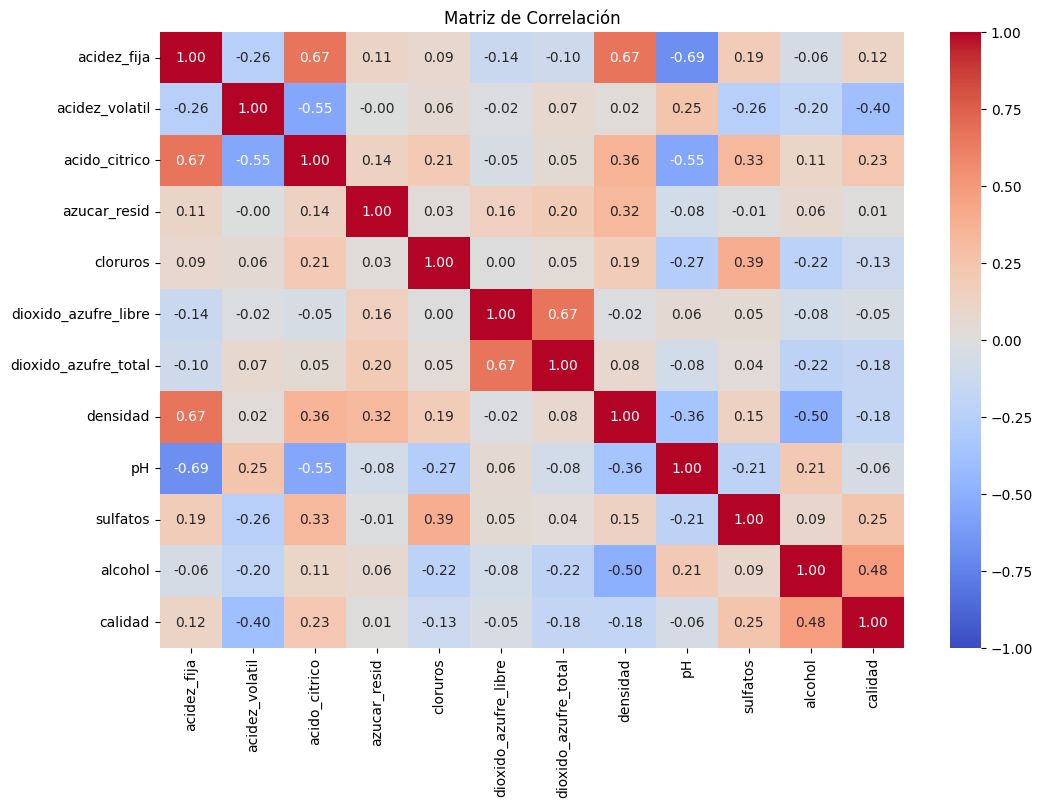

In [129]:
# Matriz de correlación
plt.figure(figsize=(12,8))

correlation = df_e.corr()

sns.heatmap(correlation,
            annot=True,
            cmap='coolwarm',
            vmin=-1,
            fmt='.2f')

plt.title('Matriz de Correlación')
plt.savefig('img/matriz_correlacion.png') 
plt.show()

Como se observa en la matriz de correlación las variables más relacionadas con la calidad son:


- la variable: ALCOHOL	&rarr;  tiene una relación: POSITIVA

- la variable: SULFATOS  &rarr;  tiene una relación: POSITIVA

- la variable: ACIDO CITRICO  &rarr; tiene una relación: POSITIVA

- la variable: ACIDEZ VOLATIL  &rarr;  tiene una relación: NEGATIVA

#### 4.2.2 RELACION ENTRE VARIABLES MAS IMPORTANTES Y LA CALIDAD


Las MEJORES variables para boxplots según la correlación del dataset son:

- la variable alcohol tiene una relación positiva muy importante con la variable calidad.
- la variable acidez volatil tiene una relación negativa muy importante con la variable calidad.
- la variable sulfatos tiene una relación moderada positiva con la variable calidad.
- la variable acido citrico tiene una relación moderada positiva con la variable calidad.



##### 4.2.1.1 RELACION ENTRE ALCOHOL Y CALIDAD

Se analiza cómo influye el alcohol en la calidad del vino.

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_25768\3499245551.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='calidad', y='alcohol', data=df_e, palette='viridis')


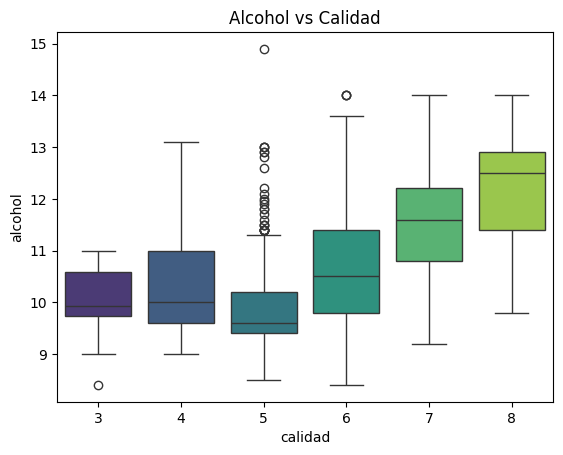

In [130]:
sns.boxplot(x='calidad', y='alcohol', data=df_e, palette='viridis')

plt.title('Alcohol vs Calidad')

plt.savefig('img/Boxplot_alcohol_calidad.png') 
plt.show()

Interpretación:

Los vinos con mayor calidad tienden a tener mayor contenido alcohólico.

##### 4.2.1.2 RELACION ENTRE ACIDEZ VOLATIL Y CALIDAD

Se estudia la relación entre la acidez volátil y la calidad.

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_25768\817794020.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='calidad', y='acidez_volatil', data=df_e, palette='viridis')


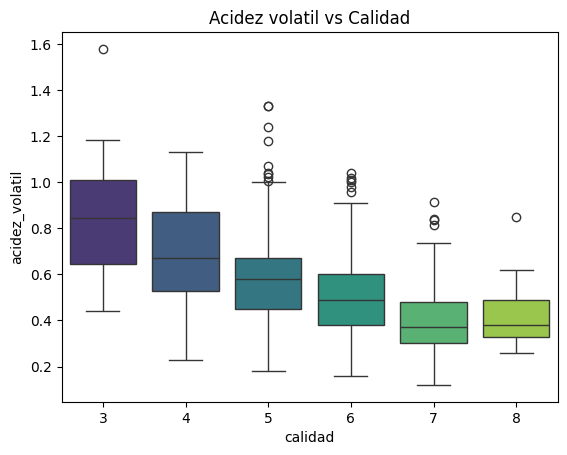

In [131]:

sns.boxplot(x='calidad', y='acidez_volatil', data=df_e, palette='viridis')

plt.title('Acidez volatil vs Calidad')

plt.savefig('img/Boxplot_acidezvolatil_calidad.png') 
plt.show()

Interpretación:

Los vinos de menor calidad presentan niveles más altos de acidez volátil.

##### 4.2.1.3 RELACION ENTRE SULFATOS Y CALIDAD

Se estudia la relación entre los sulfatos y calidad.

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_25768\1343077340.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='calidad', y='sulfatos', data=df_e, palette='viridis')


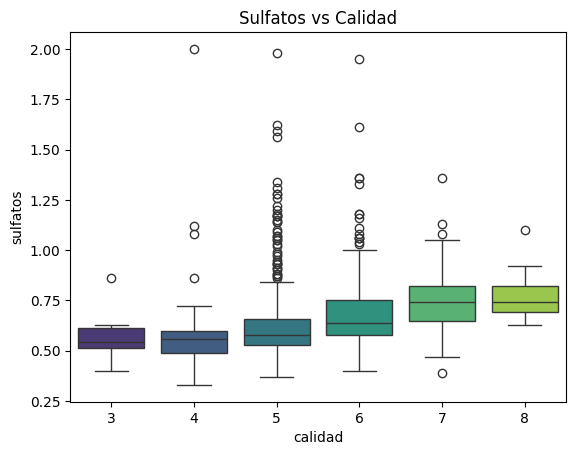

In [132]:
sns.boxplot(x='calidad', y='sulfatos', data=df_e, palette='viridis')

plt.title('Sulfatos vs Calidad')
plt.savefig('img/Boxplot_sulfatos_calidad.png') 
plt.show()

Interpretación:

Los vinos con mejores puntuaciones suelen presentar mayores niveles de sulfatos.

##### 4.2.1.4 RELACION ENTRE ACIDO CITRICO Y CALIDAD

Se estudia la relación entre el ácido cítrico y la calidad.

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_25768\2108038710.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='calidad',


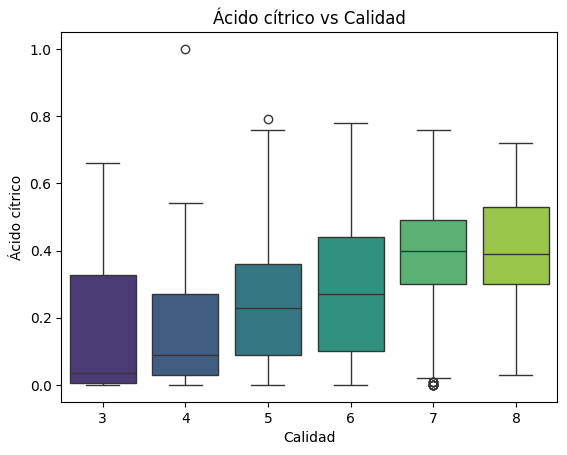

In [133]:
#plt.figure(figsize=(8,5))

sns.boxplot(x='calidad',
            y='acido_citrico',
            data=df_e,
            palette='viridis')

plt.title('Ácido cítrico vs Calidad')
plt.xlabel('Calidad')
plt.ylabel('Ácido cítrico')

plt.savefig('img/Boxplot_accitrico_calidad.png') 
plt.show()

Interpretación:

Los vinos con calidad más alta tienden a tener niveles ligeramente mayores de ácido cítrico, aunque la separación no es tan clara como en el alcohol.


## 5. MODELOS


### 5.1 MODELO DE REGRESION LINEAL

**Objetivo**



Se aplica un modelo de Regresión Lineal para predecir la variable "calidad" del vino utilizando las variables químicas del dataset. El objetivo será predecir directamente el valor numérico de la calidad del vino.


In [38]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.preprocessing import StandardScaler



**Preparación de datos**


Separar variables predictoras (X) y la variable objetivo (y).

In [39]:
# Variables independientes

X = df_e.drop(columns=['calidad'])

# Variable objetivo
y = df_e['calidad']


**División de los datos en un conjunto de entrenamiento (TRAIN - 80%) y de prueba (TEST - 20%)**

In [40]:
from sklearn.model_selection import train_test_split

In [41]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**Escalado de variables**

    


Aunque la regresión lineal no siempre lo requiere, es recomendable escalar las variables para mejorar la estabilidad numérica.

In [42]:
from sklearn.preprocessing import StandardScaler


In [43]:
# Crear escalador
scaler = StandardScaler()

# Escalar entrenamiento
X_train_scaled = scaler.fit_transform(X_train)

# Escalar test
X_test_scaled = scaler.transform(X_test)

**Crear e inicializar el modelo de Regresión Lineal**

In [44]:
from sklearn.linear_model import LinearRegression


In [45]:
# Crear modelo
lr = LinearRegression()

**Entrenar el modelo con los datos de entrenamiento**

In [46]:
lr.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


**Realizar predicciones usando el conjunto de prueba**

In [47]:
y_pred = lr.predict(X_test_scaled)

In [48]:
# Mostrar primeras predicciones
print(y_pred[:10])

[5.24560141 5.80993501 6.36840525 5.15873325 5.19928608 6.77639051
 5.70671729 4.84475677 5.79995509 5.73940516]


**Evaluar el rendimiento del modelo**



Se evalua el modelo mediante las métricas de regresión.

In [49]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, root_mean_squared_error, r2_score

In [50]:
print(f"MAE:  {mean_absolute_error(y_test, y_pred):.4f}")
print(f"MAPE: {mean_absolute_percentage_error(y_test, y_pred):.4f}")
print(f"MSE:  {mean_squared_error(y_test, y_pred):.4f}")
print(f"RMSE: {root_mean_squared_error(y_test, y_pred):.4f}")
print(f"r2:   {r2_score(y_test, y_pred):.4f}")

MAE:  0.5041
MAPE: 0.0968
MSE:  0.4310
RMSE: 0.6565
r2:   0.3915


**Explicación de las métricas**

Los resultados nos indican que el modelo de Regresión Lineal funciona de manera moderada, para predecir la calidad del vino.

- MAE = 0.5041  &rarr;  El modelo se equivoca en ±0.5 puntos de calidad.

- MAPE = 0.0968  &rarr;  El modelo tiene aproximadamente 9.68% de error promedio. Las predicciones se desvian un 9.68 % respecto al valor real. 

- MSE = 0.4310  &rarr;  Penaliza mucho los errores grandes, en este caso el valor no es alto lo que indica que no hay demasiadas predicciones extremadamente malas.

- RMSE = 0.6565  &rarr;  El error típico del modelo es aproximadamente ±0.66 puntos de calidad.

- R² = 0.3915  &rarr;  El modelo explica aproximadamenten el 39.15% de la variación en la calidad del vino.


EN RESUMEN:

- Errores relativamente bajos
- Predicciones razonables
- Solo explica el 39.15 % de la calidad




El modelo de Regresión Lineal obtuvo un MAE de 0.5041 y un RMSE de 0.6565, lo que indica que las predicciones presentan errores moderados respecto a la calidad real del vino. El MAPE de 9.68% muestra que el error porcentual promedio es relativamente bajo. Sin embargo, el R² = 0.3915 indica que el modelo solo logra explicar aproximadamente el 39.15% de la variabilidad de la calidad del vino, lo que sugiere que existen relaciones en los datos que la regresión lineal no consigue modelar completamente.



**ANALISIS DE LOS COEFICIENTES**


In [51]:
#  Ver la importancia de cada característica (Coeficientes)
coeficientes = pd.DataFrame({'Característica': X.columns, 'Coeficiente': lr.coef_})
coeficientes = coeficientes.sort_values(by='Coeficiente', ascending=False)

print("IMPACTO DE CADA VARIABLE EN LA CALIDAD:")
print(coeficientes.to_string(index=False))

IMPACTO DE CADA VARIABLE EN LA CALIDAD:
      Característica  Coeficiente
             alcohol     0.333970
            sulfatos     0.148499
dioxido_azufre_libre     0.048723
            densidad     0.042064
        azucar_resid    -0.005231
       acido_citrico    -0.019148
         acidez_fija    -0.049675
            cloruros    -0.115971
                  pH    -0.121548
dioxido_azufre_total    -0.123600
      acidez_volatil    -0.178494


A continuación se representa en un gráfico el impacto de las variables en la calidad del vino.

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_25768\2986451260.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


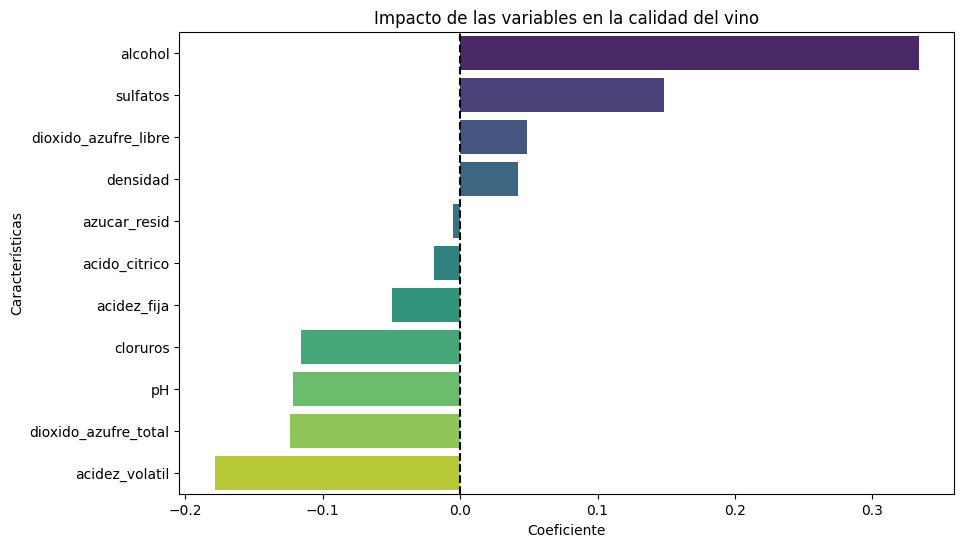

In [53]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=coeficientes,
    x='Coeficiente',
    y='Característica',
    palette='viridis'
)

plt.axvline(x=0, color='black', linestyle='--')

plt.title('Impacto de las variables en la calidad del vino')
plt.xlabel('Coeficiente')
plt.ylabel('Características')

plt.show()

EXPLICACION DEL GRAFICO:

- Barras hacia la derecha (+) → aumentan la calidad.
- Barras hacia la izquierda (-) → disminuyen la calidad.
- Cuanto más larga la barra → mayor influencia.
- La línea vertical en 0 separa efectos positivos y negativos.

El resultado anterior nos dice las variables que aumentan o disminuyen la calidad del vino y cuánto influyen.

Variables que AUMENTAN la calidad:

- Alcohol = +0.334  $\Rightarrow$  Es la variable MÁS importante del modelo. A mayor contenido de alcohol, mayor calidad del vino.

- Sulfatos = +0.148  $\Rightarrow$  Segunda variable positiva más importante. Niveles más altos de sulfatos se relacionan con mejor calidad.

    Los sulfatos ayudan:
    - estabilidad
    - conservación
    - sabor

Variables que tienen POCA influencia en la predicción:
- dióxido azufre libre = +0.049
- densidad = +0.042
- azúcar residual = -0.005


Variables que DISMINUYEN la calidad:

- acidez volátil = -0.178  $\Rightarrow$  Es la variable negativa MÁS importante. Cuando aumenta la acidez volátil, la calidad disminuye.

    La acidez volátil puede generar:
    - sabores desagradables 
    - olor a vinagre.

- dióxido azufre total = -0.124  $\Rightarrow$  Concentraciones altas de dióxido de azufre total se relacionan con menor calidad.
- cloruros = -0.116  $\Rightarrow$  Altos niveles de salinidad/cloruros empeoran la calidad.
- pH = -0.122  $\Rightarrow$  Valores altos de pH reducen ligeramente la calidad.


##### CONCLUSION GLOBAL DEL MODELO SOBRE LAS VARIABLES: 

Mejora la calidad del vino:

✅ alcohol

✅ sulfatos

Empeora la calidad del vino:

❌ acidez volátil

❌ exceso de dióxido de azufre total

❌ cloruros


**Visualización de predicciones**

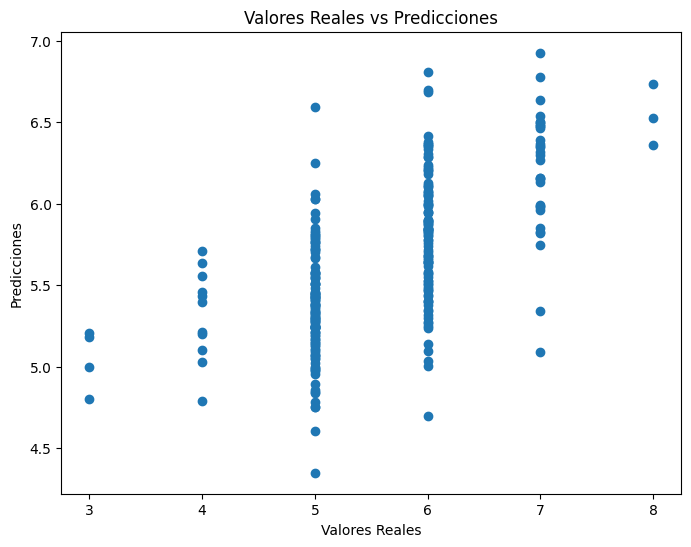

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Valores Reales")
plt.ylabel("Predicciones")

plt.title("Valores Reales vs Predicciones")

plt.show()

El gráfico de valores reales vs predicciones muestra que el modelo de regresión lineal logra capturar parcialmente la tendencia general de la calidad del vino, ya que las predicciones aumentan conforme aumentan los valores reales. Sin embargo, las predicciones se concentran principalmente entre valores medios, mostrando dificultades para estimar correctamente las calidades extremas. Además, la dispersión observada para un mismo valor real indica que el modelo presenta errores moderados y no consigue explicar completamente la variabilidad presente en los datos. Esto sugiere que la relación entre las variables químicas y la calidad del vino no es completamente lineal.

**Conclusión del modelo**

La regresión lineal permite modelar la relación entre las propiedades químicas del vino y su calidad mediante una combinación lineal de variables predictoras. Aunque ofrece una interpretación sencilla y rápida, su rendimiento puede verse limitado debido a la complejidad y no linealidad presente en los datos del dataset de vinos.


### 5.2 INTRODUCCION A LOS MODELOS DE CLASIFICACION

Inicialmente se abordó el problema mediante un modelo de Regresión Lineal con el objetivo de predecir directamente la puntuación de calidad del vino. Sin embargo, los resultados obtenidos mostraron una capacidad predictiva limitada, el modelo solo era capaz de explicar aproximadamente el 38% de la variabilidad de la calidad por lo 
se reformula el problema como una tarea de clasificación binaria para mejorar la capacidad predictiva del modelo y facilitar la interpretación de los resultados. En dicha clasificación binaria se agrupan los vinos en dos categorías: vinos de buena calidad (calidad ≥ 6) y vinos de mala calidad (calidad < 6). 

Lo que ha permitido utilizar algoritmos de clasificación para obtener un rendimiento superior al alcanzado mediante el modelo de Regresión Lineal.

Los modelos estudiados son:

- Logistic Regression
- KNN
- Decision Tree
- Random Forest
- SVM

### **MODELOS DE CLASIFICACION**

Para transformar el problema en uno de clasificación binaria se agrupa la variable calidad en dos categorías:

- Buena calidad  &rarr; 1 (calidad ≥ 6)
- Mala calidad  &rarr;  0 (calidad < 6)

In [1]:
import pandas as pd

# Visualización 
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
df_e = pd.read_csv ("data_new/df_e.csv")

####    PREPARACION DE LOS DATOS

Se transforma el dataset "df_e" en "df_clf". 

Primero se hace una copia del dataset y luego se transfoma.

In [3]:
df_clf = df_e.copy()



In [4]:
#  Se convierte calidad en variable binaria

df_clf['calidad'] = df_clf['calidad'].apply(lambda x: 1 if x >= 6 else 0)
df_clf

,acidez_fija,acidez_volatil,acido_citrico,azucar_resid,cloruros,dioxido_azufre_libre,dioxido_azufre_total,densidad,pH,sulfatos,alcohol,calidad
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,0
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,0
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,0
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,1
4,7.4,0.660,0.00,1.8,0.075,13.0,40.0,0.99780,3.51,0.56,9.4,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1354,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,1
1355,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,0
1356,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,1
1357,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,0


In [5]:

# Separar variables
X = df_clf.drop('calidad', axis=1)
y = df_clf['calidad']

In [6]:
df_clf

,acidez_fija,acidez_volatil,acido_citrico,azucar_resid,cloruros,dioxido_azufre_libre,dioxido_azufre_total,densidad,pH,sulfatos,alcohol,calidad
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,0
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,0
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,0
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,1
4,7.4,0.660,0.00,1.8,0.075,13.0,40.0,0.99780,3.51,0.56,9.4,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1354,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,1
1355,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,0
1356,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,1
1357,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,0


Esta transformación simplifica el problema de predicción y permite aplicar algoritmos de clasificación binaria. Además, facilita la interpretación de resultados y el análisis de métricas como accuracy, precision y recall.


In [7]:
# Verificar distribucion
calidad_counts = (
    df_clf["calidad"]
    .value_counts()
    .sort_index()
    .reset_index()
)

calidad_counts.columns = ["Calidad", "Frecuencia"]

print(calidad_counts.to_string(index=False))

 Calidad  Frecuencia
       0         640
       1         719


Se hace una clasificación binaria para obtener una distribución bastante equilibrada entre ambas clases. El 52.91% de los vinos fueron clasificados como de buena calidad y el 47.09% como de mala calidad. Este equilibrio es favorable para el entrenamiento de modelos de Machine Learning, ya que reduce problemas asociados al desbalanceo de clases.

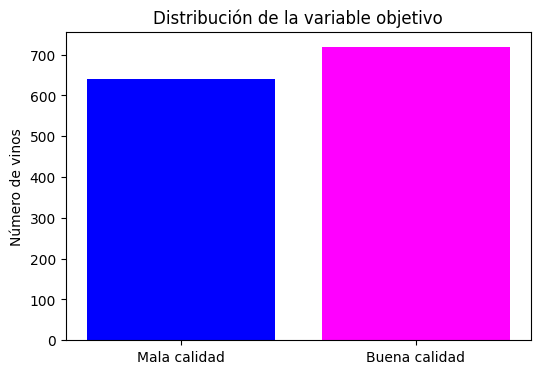

In [10]:
import matplotlib.pyplot as plt

calidades = ['Mala calidad', 'Buena calidad']
frecuencias = [640, 719]

plt.figure(figsize=(6,4))
plt.bar(calidades, frecuencias, color=['blue','magenta'])

plt.title('Distribución de la variable objetivo')
plt.ylabel('Número de vinos')

plt.show()

In [ ]:
# Separar variables predictoras y objetivo
# Variables predictoras
X = df_clf.drop('calidad', axis=1)

# variables objetivo que el modelo intenta predecir
y = df_clf['calidad']

In [12]:
from sklearn.model_selection import train_test_split

# Division de los datos en entrenamiento (TRAIN - 80%) y de prueba (TEST-20%)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y    # mantiene la proporcion de clases en ambos conjuntos
)

In [13]:
from sklearn.preprocessing import StandardScaler

# Escalado de variables

# Crear escalador
scaler = StandardScaler()

# Ajustar y transformar entrenamiento
X_train_scaled = scaler.fit_transform(X_train)

# Transformar test
X_test_scaled = scaler.transform(X_test)

#### 5.2.1 Logistic Regression

La regresión logística es un modelo lineal utilizado para clasificación binaria. Predice la probabilidad de pertenecer a una clase.

In [14]:
from sklearn.linear_model import LogisticRegression

# Crear modelo

logr= LogisticRegression(random_state=42)


# Entrenar el modelo

logr.fit(X_train_scaled, y_train)


# Predicciones

y_pred_logr = logr.predict(X_test_scaled)


# Evaluar el rendimiento del modelo

from sklearn.metrics import accuracy_score


# Accuracy
acc_logr = accuracy_score(y_test, y_pred_logr)

print("Accuracy Logisctic Regression:", acc_logr)




Accuracy Logisctic Regression: 0.7352941176470589


#### 5.2.2 K-Nearest Neighbors (KNN)

KNN clasifica observaciones según las clases de sus vecinos más cercanos.

In [15]:
from sklearn.neighbors import KNeighborsClassifier

# Crear modelo
knn = KNeighborsClassifier(n_neighbors=5)

# Entrenar
knn.fit(X_train_scaled, y_train)

# Predicciones
y_pred_knn = knn.predict(X_test_scaled)

# Accuracy
acc_knn = accuracy_score(y_test, y_pred_knn)

print("Accuracy KNN:", acc_knn)


Accuracy KNN: 0.6875


#### 5.2.3 Decision Tree

Los árboles de decisión generan reglas basadas en divisiones sucesivas de las variables.

In [16]:
from sklearn.tree import DecisionTreeClassifier

# Crear modelo
dt = DecisionTreeClassifier(random_state=42)

# Entrenar
dt.fit(X_train, y_train)

# Predicciones
y_pred_dt = dt.predict(X_test)

# Accuracy
acc_dt = accuracy_score(y_test, y_pred_dt)

print("Accuracy Decision Tree:", acc_dt)

Accuracy Decision Tree: 0.625


#### 5.2.4 Random Forest

Random Forest combina múltiples árboles de decisión para mejorar la precisión y reducir overfitting.


In [17]:
from sklearn.ensemble import RandomForestClassifier

# Crear modelo
rf = RandomForestClassifier(random_state=42)

# Entrenar
rf.fit(X_train, y_train)

# Predicciones
y_pred_rf = rf.predict(X_test)

# Accuracy
acc_rf = accuracy_score(y_test, y_pred_rf)

print("Accuracy Random Forest:", acc_rf)

Accuracy Random Forest: 0.75


#### 5.2.5 Support Vector Machine (SVM)

SVM busca encontrar el hiperplano óptimo que mejor separa las clases.

In [19]:
from sklearn.svm import SVC

# Crear modelo
svm = SVC(probability=True)

# Entrenar
svm.fit(X_train_scaled, y_train)

# Predicciones
y_pred_svm = svm.predict(X_test_scaled)

# Accuracy
acc_svm = accuracy_score(y_test, y_pred_svm)

print("Accuracy SVM:", acc_svm)

Accuracy SVM: 0.7536764705882353


### 5.3 COMPARACION DE MODELOS

#### 5.3.1 ACCURACY

Se comparan los modelos mediante la métrica Accuracy para identificar cuál presenta mejor rendimiento sobre el conjunto de prueba.

In [20]:
results = pd.DataFrame({
    'Modelo': [
        'Logistic Regression',
        'KNN',
        'Decision Tree',
        'Random Forest',
        'SVM'
    ],
    
    'Accuracy': [
        acc_logr,
        acc_knn,
        acc_dt,
        acc_rf,
        acc_svm
    ]
})

results.sort_values(by='Accuracy',
                    ascending=False)

,Modelo,Accuracy
4,SVM,0.753676
3,Random Forest,0.750000
0,Logistic Regression,0.735294
1,KNN,0.687500
2,Decision Tree,0.625000


##### Comparación visual del valor de la accuracy para los distintos modelos estudiados

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_25768\3733719920.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


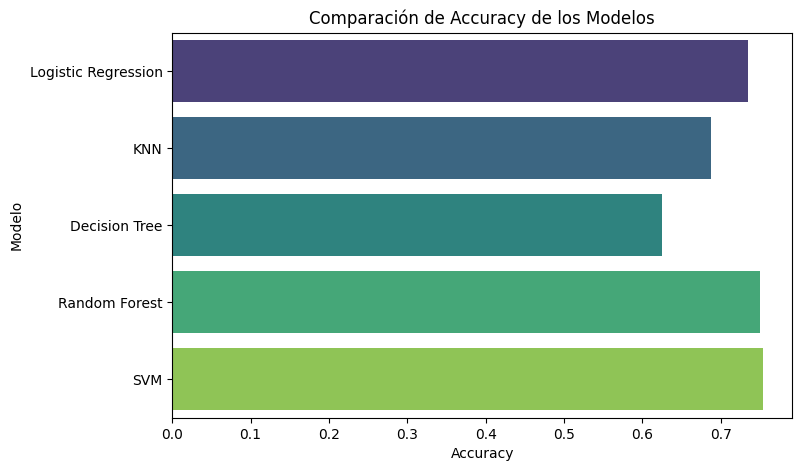

In [21]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x='Accuracy',
    y='Modelo',
    palette='viridis'
)

plt.title('Comparación de Accuracy de los Modelos')
plt.xlabel('Accuracy')
plt.ylabel('Modelo')

plt.show()

Tras entrenar y evaluar cinco algoritmos de clasificación, el modelo Support Vector Machine (SVM) obtuvo el mejor rendimiento con una exactitud del 75.37%, seguido muy de cerca por Random Forest con un 75.00%. Ambos modelos superaron a Logistic Regression, KNN y Decision Tree. Por tanto, SVM fue seleccionado como modelo final al presentar la mayor capacidad predictiva sobre el conjunto de prueba.

#### 5.3.2 MATRIZ DE CONFUSION

In [22]:
# Matriz de confusión
from sklearn.metrics import confusion_matrix

##### 5.3.2.1 MATRIZ DE CONFUSION modelo Logistic Regresion

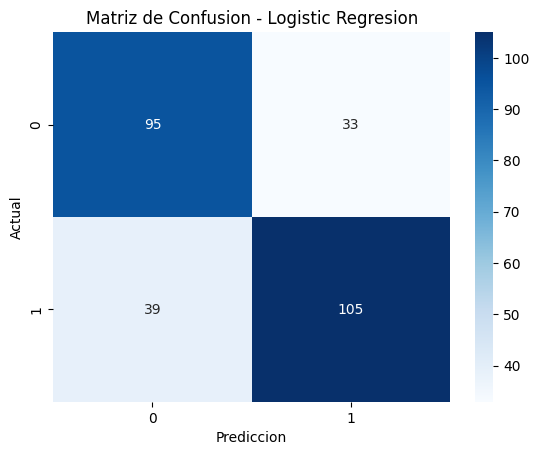

In [23]:

cm = confusion_matrix(y_test,
                      y_pred_logr)

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title('Matriz de Confusion - Logistic Regresion')
plt.xlabel('Prediccion')
plt.ylabel('Actual')

plt.show()

##### 5.3.2.2 MATRIZ DE CONFUSION modelo KNN

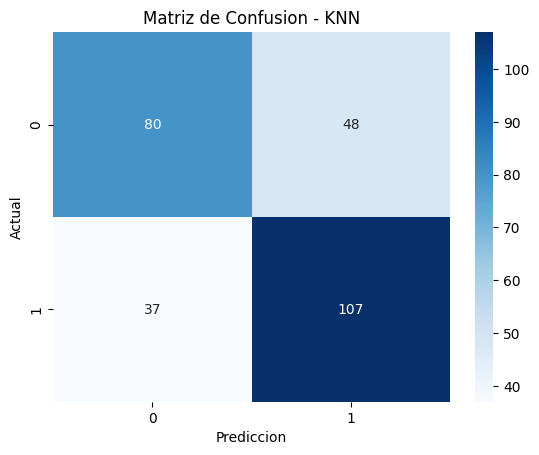

In [24]:
cm = confusion_matrix(y_test,
                      y_pred_knn)

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title('Matriz de Confusion - KNN')
plt.xlabel('Prediccion')
plt.ylabel('Actual')

plt.show()

##### 5.3.2.3 MATRIZ DE CONFUSION modelo Decision Tree

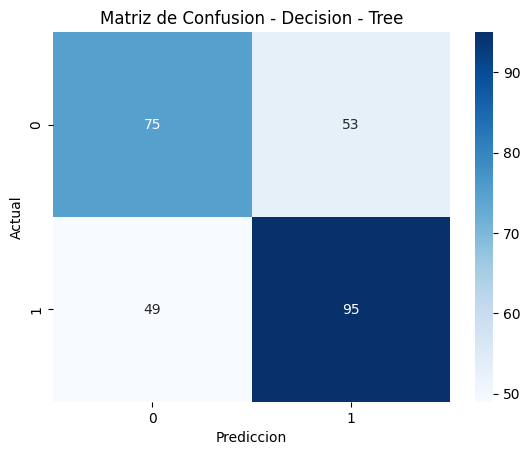

In [25]:
cm = confusion_matrix(y_test,
                      y_pred_dt)

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title('Matriz de Confusion - Decision - Tree')
plt.xlabel('Prediccion')
plt.ylabel('Actual')

plt.show()

##### 5.3.2.4 MATRIZ DE CONFUSION modelo Random Forest

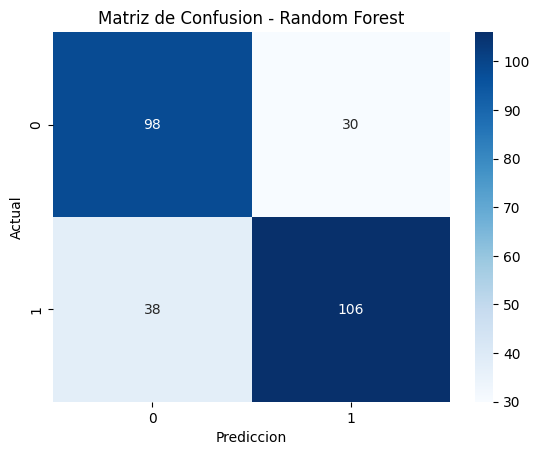

In [26]:
cm = confusion_matrix(y_test,
                      y_pred_rf)

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title('Matriz de Confusion - Random Forest')
plt.xlabel('Prediccion')
plt.ylabel('Actual')

plt.show()

##### 5.3.2.5 MATRIZ DE CONFUSION modelo SVM

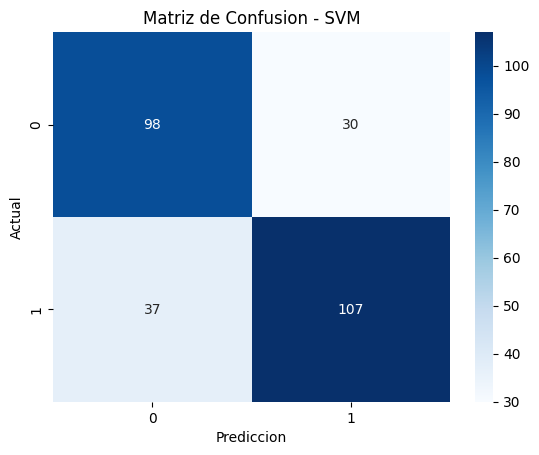

In [27]:
cm = confusion_matrix(y_test,
                      y_pred_svm)

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title('Matriz de Confusion - SVM')
plt.xlabel('Prediccion')
plt.ylabel('Actual')

plt.show()

##### CONCLUSION MATRIZ DE CONFUSION

El análisis de las matrices de confusión muestra que los modelos Random Forest y SVM presentan el mejor comportamiento, obteniendo el mayor número de clasificaciones correctas y el menor número de errores. Por el contrario, Decision Tree es el modelo con peor rendimiento, mostrando una elevada cantidad de falsos positivos y falsos negativos. Logistic Regression ofrece resultados equilibrados y constituye una buena línea base, mientras que KNN presenta dificultades para identificar correctamente los vinos de baja calidad. 

SVM  &rarr;  Se selecciona como el modelo final al lograr el menor número de errores de clasificación y la mayor exactitud global (75.37%).

### 5.4 NUESTRO MODELO

#### 5.4.1 METRICAS DE NUESTRO MODELO

A continuación se calculan las métricas para el modelo elegido SVM.

In [28]:
# Classification Report
from sklearn.metrics import classification_report

print ("=============     SVM   ================")
print(classification_report(y_test,
                            y_pred_svm))
print ('------------------------')


=============     SVM   ================
              precision    recall  f1-score   support

           0       0.73      0.77      0.75       128
           1       0.78      0.74      0.76       144

    accuracy                           0.75       272
   macro avg       0.75      0.75      0.75       272
weighted avg       0.76      0.75      0.75       272

------------------------


El modelo Support Vector Machine (SVM) es el modelo que tiene el mejor rendimiento entre todos los modelos evaluados, alcanzando una exactitud (Accuracy) del 75%.

Para la clase 0 (vinos de mala calidad):
- el modelo obtuvo una precisión del 73%, lo que indica que cuando clasifica un vino como de mala calidad, acierta en el 73% de los casos.
- Recall fue del 77%, lo que significa que identifica correctamente el 77% de todos los vinos realmente clasificados como de mala calidad.
- F1-score alcanzó un valor de 0.75, reflejando un buen equilibrio entre precisión y capacidad de detección.

Para la clase 1 (vinos de buena calidad):
- la precisión fue del 78%, indicando que cuando el modelo predice que un vino es de buena calidad, acierta en el 78% de las ocasiones. 
- Recall obtenido fue del 74%, por lo que detecta correctamente el 74% de los vinos que realmente pertenecen a esta categoría. 
- F1-score fue de 0.76, ligeramente superior al de la clase 0.

Los valores de macro average y weighted average se sitúan en torno al 75%, lo que indica que el rendimiento del modelo es equilibrado entre ambas clases y que no existe un sesgo significativo hacia los vinos de buena o mala calidad.

En conjunto, estos resultados muestran que el modelo SVM posee una buena capacidad de generalización y un comportamiento equilibrado en la clasificación de vinos, lo que justifica su selección como modelo final del proyecto.

#### 5.4.2  GUARDAR EL MODELO

Una vez seleccionado SVM como modelo final, se ha almacenado utilizando la librería Joblib en formato .pkl. También se ha guardado el objeto de escalado empleado durante el entrenamiento para garantizar que futuras predicciones se realicen bajo las mismas condiciones que los datos utilizados para entrenar el modelo.

In [29]:
import joblib

joblib.dump(svm, 'modelo_svm.pkl')

['modelo_svm.pkl']

Como SVM se entrenó con datos escalados, es muy importante guardar también el StandardScaler:

In [30]:
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [31]:
# Para cargar el modelo posteriormente
import joblib

modelo_svm = joblib.load('modelo_svm.pkl')
scaler = joblib.load('scaler.pkl')

In [32]:
# modelos cargados en la carpeta MODELOS

import joblib

joblib.dump(svm, 'modelos/modelo_svm.pkl')
joblib.dump(scaler, 'modelos/scaler.pkl')



['modelos/scaler.pkl']

In [33]:
# modelos en carpeta modelos

# Cargar el modelo posteriormente
import joblib

modelo_svm = joblib.load('modelos/modelo_svm.pkl')
scaler = joblib.load('modelos/scaler.pkl')

In [34]:
# EJEMPLO DE PRUEBA

nuevo_vino = [[7.4, 0.70, 0.00, 1.9, 0.076,
               11, 34, 0.9978, 3.51, 0.56, 9.4]]

# se escala
nuevo_vino_scaled = scaler.transform(nuevo_vino)

# se predice
prediccion = modelo_svm.predict(nuevo_vino_scaled)

print(prediccion)

# Resultado si es 1 --> Buena calidad    si es 0 --> Mala calidd

[0]


c:\Users\USUARIO\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


#### 5.4.3 OPTIMIZACION DEL MODELO SELECCIONADO

Ahora se hace una optimización de hiperparámetros para intentar mejorar ese 75.37%.

**Se buscan los mejores parámetros:**

In [35]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf']
}

grid = GridSearchCV(
    SVC(),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

print("Mejores parámetros:")
print(grid.best_params_)

print("\nMejor accuracy CV:")
print(grid.best_score_)

Mejores parámetros:
{'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}

Mejor accuracy CV:
0.7442438591299201


**Se obtiene el mejor SVM:**

In [36]:
best_svm = grid.best_estimator_

**Se evalua sobre Test:**

In [37]:
from sklearn.metrics import accuracy_score

y_pred_best = best_svm.predict(X_test_scaled)

acc_best = accuracy_score(
    y_test,
    y_pred_best
)

print("Accuracy optimizado:", acc_best)

Accuracy optimizado: 0.7389705882352942


**Se compara:**

Con esos resultados, se llega a la siguiente conclusión:


- MODELO: SVM original  &rarr;  ACCURACY: 75.36%. Es el rendimiento real que se obtiene sobre el conjunto de test, 75.36% de los vinos fueron clasificados correctamente.

- MODELO: SVM optimizado (GridSearch)  &rarr;  ACCURACY: 73.90%. En promedio, durante la validación cruzada, el modelo acertó un 74.42%.

- Mejor Accuracy CV  &rarr;  ACCURACY: 74.42%. Es el resultado cuando se cogen los siguienes parámetros óptimos: `C=10`, `gamma=0.01`, `kernel='rbf'` y los evalúas sobre el conjunto de test.

El GridSearch busca los parámetros que mejor funcionan sobre el conjunto de entrenamiento mediante validación cruzada. Aunque eso no garantiza que también sean los mejores para el conjunto de test.


El modelo elegido es el **SVM original** porque el criterio final siempre debe ser el rendimiento sobre el conjunto de prueba.

In [31]:
print(grid.best_params_)
print(grid.best_score_)

{'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
0.7442438591299201


Se selecciona SVM como el mejor algoritmo de clasificación, y después se realiza un proceso de optimización de hiperparámetros mediante GridSearchCV. La mejor combinación encontrada fue C = 10, gamma = 0.01 y kernel RBF, obteniendo una exactitud media en validación cruzada del 74.42%. Sin embargo, al evaluar este modelo sobre el conjunto de prueba, la exactitud descendió hasta el 73.90%, situándose por debajo del 75.36% alcanzado por el modelo SVM con parámetros por defecto. Por lo que se decidió conservar **la versión original de SVM como modelo final del proyecto**.

## **CONCLUSION FINAL:**

El proyecto demuestra que las características fisicoquímicas permiten predecir la calidad del vino con un nivel de precisión aceptable. Entre los modelos evaluados, SVM obtuvo el mejor rendimiento, alcanzando una accuracy del 75.37%. Los resultados muestran que variables como el alcohol y los sulfatos tienen una influencia positiva sobre la calidad, mientras que la acidez volátil y el dióxido de azufre total presentan una influencia negativa.

## AGRADECIMIENTOS

P. Cortez, A. Cerdeira, F. Almeida, T. Matos y J. Reis. Modelado de preferencias de vino mediante minería de datos a partir de propiedades fisicoquímicas. En Decision Support Systems, Elsevier, 47(4):547-553, 2009.


## BIBLIOGRAFIA

Publicación:

P. Cortez, A. Cerdeira, F. Almeida, T. Matos y J. Reis. Modelado de preferencias de vino mediante minería de datos a partir de propiedades fisicoquímicas.
En Decision Support Systems, Elsevier, 47(4):547-553, 2009.